# 시군구 관광연관지표 wide 테이블


## 분석 목적과 범위

국민여행조사 전용 지역코드의 시도+시군구 229개를 key로 하여, 시군구
단위 관광연관 지표를 wide 형태로 결합한다.

- 시군구별 면적(km^2)
- 관광지유형별(9종) 개수·면적당 밀도, 관광지 총개수·총밀도
- 상권업종 중분류(75종) 기준 개수·밀도
- 상권업종 대분류 중 음식점업, 예술·스포츠 및 여가관련 서비스업,
  숙박업(기타 숙박업 제외)의 개수·밀도
- 그 외 관광과 관련 있다고 판단한 업종(여행사, 기념품·장식품 소매업,
  욕탕·신체관리서비스업)의 개수·밀도
- 위 관광연관업종 개수의 총합

이 표는 이후 관광연관지표와 국민여행조사 방문 데이터를 결합하는
분석의 입력으로 쓴다. 여기서는 결합·전처리와 각 변수의 단계구분도까지만
다룬다.

## 행정구역 표기 보정

- 국민여행조사 전용 지역코드는 군위군을 경상북도로 표기한다(2023년
  대구광역시 편입 이전 명칭). 앞으로의 데이터는 군위군을 대구광역시로
  표기하므로, 이 노트북은 원본 CSV는 그대로 두고 key 테이블 안에서만
  군위군의 시도명을 대구광역시로 고친다.
- 시군구 경계 geojson은 인천 남구를 2018년 개칭된 미추홀구로, 관광지
  geojson과 상가정보도 마찬가지로 미추홀구를 쓴다. 지역코드가 쓰는 옛
  이름(남구)에 맞춰 결합 전에 고친다.
- 관광지 geojson과 상가정보는 `강원특별자치도`(→ 강원도),
  `전북특별자치도`(→ 전라북도), `서울`(→ 서울특별시)처럼 지역코드와
  다른 시도 표기를 쓴다.
- 세종은 상가정보의 시군구명이 `세종특별자치시`로 지역코드의
  `세종시`와 다르다.
- 위 보정은 모두 이 노트북 코드 안에서만 적용하고 원본 파일은 고치지
  않는다.

## 환경, 공통 경로, 재현성 설정

In [1]:
from pathlib import Path
import glob
import sys
import warnings

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "src").is_dir():
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        raise FileNotFoundError("src 폴더가 있는 프로젝트 루트를 찾지 못했습니다.")
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap

from src.path import NATIONAL_TRAVEL_SURVEY_RAW_DATA_DIR, RAW_DATA_DIR, create_output_directories
from src.visualization import COLORS, apply_plot_style

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 20)
apply_plot_style()
FIGURES_DIR, TABLES_DIR = create_output_directories(
    "260722_시군구_관광연관지표_와이드테이블.ipynb"
)

REGION_CODE_PATH = (
    NATIONAL_TRAVEL_SURVEY_RAW_DATA_DIR / "national_travel_survey_region_code.csv"
)
SIGUNGU_GEOJSON_PATH = RAW_DATA_DIR / "sigungu_map" / "전국_시군구_2025_2Q.geojson"
TOUR_SITE_GEOJSON_PATH = (
    RAW_DATA_DIR / "tour_site" / "전국관광지정보표준데이터_관광지유형추가.geojson"
)
MARKET_DATA_DIR = RAW_DATA_DIR / "market_20251231"
MARKET_FILE_PATHS = sorted(MARKET_DATA_DIR.glob("소상공인시장진흥공단_상가*.csv"))

# 시군구 경계 SIGUNGU_CD 앞 2자리 -> 지역코드가 쓰는 시도명
PROVINCE_BY_CODE_PREFIX = {
    "11": "서울특별시", "21": "부산광역시", "22": "대구광역시", "23": "인천광역시",
    "24": "광주광역시", "25": "대전광역시", "26": "울산광역시", "29": "세종특별자치시",
    "31": "경기도", "32": "강원도", "33": "충청북도", "34": "충청남도",
    "35": "전라북도", "36": "전라남도", "37": "경상북도", "38": "경상남도",
    "39": "제주특별자치도",
}
# 관광지 geojson·상가정보가 지역코드와 다르게 쓰는 시도명 표기
SIDO_NAME_FIX = {
    "강원특별자치도": "강원도",
    "전북특별자치도": "전라북도",
    "서울": "서울특별시",
}

print(f"지역코드: {REGION_CODE_PATH.relative_to(PROJECT_ROOT)}")
print(f"시군구 경계: {SIGUNGU_GEOJSON_PATH.relative_to(PROJECT_ROOT)}")
print(f"관광지: {TOUR_SITE_GEOJSON_PATH.relative_to(PROJECT_ROOT)}")
print(f"상가정보 파일 수: {len(MARKET_FILE_PATHS)}")

지역코드: data\raw\national_travel_survey\national_travel_survey_region_code.csv
시군구 경계: data\raw\sigungu_map\전국_시군구_2025_2Q.geojson
관광지: data\raw\tour_site\전국관광지정보표준데이터_관광지유형추가.geojson
상가정보 파일 수: 17


## 1. 데이터 로드

In [2]:
region_code = pd.read_csv(REGION_CODE_PATH)
sigungu_gdf = gpd.read_file(SIGUNGU_GEOJSON_PATH)

import json

with open(TOUR_SITE_GEOJSON_PATH, encoding="utf-8") as f:
    tour_site_raw = json.load(f)

print(f"지역코드 행 수: {len(region_code)}")
print(f"시군구 경계 원본 행 수(구 단위 포함): {len(sigungu_gdf)}")
print(f"관광지 수: {len(tour_site_raw['features'])}")

지역코드 행 수: 229
시군구 경계 원본 행 수(구 단위 포함): 252
관광지 수: 854


## 2. 데이터 품질과 분석 단위 확인

분석 단위는 시군구(국민여행조사 전용 지역코드 229행)다. 결합 전에
군위군·인천 남구/미추홀구 표기 차이와 관광지 주소 결측을 확인한다.

In [3]:
assert region_code[["시도_코드", "시군구_코드"]].drop_duplicates().shape[0] == len(
    region_code
), "지역코드에 (시도_코드, 시군구_코드) 중복이 있습니다."

gunwi_row = region_code.loc[region_code["시군구명"] == "군위군"]
print(f"보정 전 지역코드 군위군 시도명: {gunwi_row['시도명'].iloc[0]}")

gunwi_geo = sigungu_gdf.loc[sigungu_gdf["SIGUNGU_NM"] == "군위군", "SIGUNGU_CD"]
print(f"시군구 경계 군위군 SIGUNGU_CD: {gunwi_geo.iloc[0]} (22XXX=대구광역시)")

print(
    "시군구 경계 인천 미추홀구 존재 여부: "
    f"{(sigungu_gdf['SIGUNGU_NM'] == '미추홀구').any()}, "
    "지역코드 인천 남구 존재 여부: "
    f"{((region_code['시도명'] == '인천광역시') & (region_code['시군구명'] == '남구')).any()}"
)

missing_addr = sum(
    1
    for feat in tour_site_raw["features"]
    if not (feat["properties"].get("소재지지번주소") or feat["properties"].get("소재지도로명주소"))
)
print(f"주소가 모두 없는 관광지 수: {missing_addr}")

tour_type_counts = pd.Series(
    [feat["properties"].get("관광지유형") for feat in tour_site_raw["features"]]
).value_counts()
print("관광지유형별 원자료 개수:")
print(tour_type_counts)

보정 전 지역코드 군위군 시도명: 경상북도
시군구 경계 군위군 SIGUNGU_CD: 22520 (22XXX=대구광역시)
시군구 경계 인천 미추홀구 존재 여부: True, 지역코드 인천 남구 존재 여부: True
주소가 모두 없는 관광지 수: 0
관광지유형별 원자료 개수:
문화시설/전시    184
자연/생태      181
역사/문화유산    170
레저/스포츠     106
축제/테마       65
휴양/온천       61
경관/전망       49
체험/교육       27
상업/거리       11
Name: count, dtype: int64


## 3. 전처리 — key 테이블(시군구 229행) 확정

지역코드의 군위군 시도명만 대구광역시로 고쳐 이 노트북에서 쓰는 key
테이블을 만든다. 원본 CSV는 고치지 않는다.

In [4]:
key_table = region_code[["시도명", "시군구명"]].copy()
key_table.loc[key_table["시군구명"] == "군위군", "시도명"] = "대구광역시"

assert key_table.duplicated().sum() == 0, "key 테이블에 중복 (시도명, 시군구명)이 있습니다."
print(f"key 테이블 행 수: {len(key_table)}")
print(
    "보정 후 군위군 시도명: "
    f"{key_table.loc[key_table['시군구명'] == '군위군', '시도명'].iloc[0]}"
)

key 테이블 행 수: 229
보정 후 군위군 시도명: 대구광역시


## 4. 전처리 — 시군구 경계 도시 단위 집계와 면적 계산

시군구 경계에 시도명을 붙이고, 구 단위로 나뉜 도시(수원시 등)를
key 테이블과 같은 도시 단위로 `dissolve`한다. 인천 미추홀구는 key
테이블이 쓰는 옛 이름 남구로 고친다. 면적은 등적에 가까운 한국
투영좌표계(EPSG:5179, 단위 m)로 재투영해 계산한다.

In [5]:
sigungu_gdf["시도명"] = sigungu_gdf["SIGUNGU_CD"].str[:2].map(PROVINCE_BY_CODE_PREFIX)
assert sigungu_gdf["시도명"].notna().all(), "매핑되지 않은 SIGUNGU_CD가 있습니다."

sigungu_gdf["시군구명"] = sigungu_gdf["SIGUNGU_NM"].str.split(" ").str[0]
is_incheon_michuhol = (sigungu_gdf["시도명"] == "인천광역시") & (
    sigungu_gdf["시군구명"] == "미추홀구"
)
sigungu_gdf.loc[is_incheon_michuhol, "시군구명"] = "남구"

city_gdf = sigungu_gdf.dissolve(by=["시도명", "시군구명"], as_index=False)[
    ["시도명", "시군구명", "geometry"]
]

city_gdf_projected = city_gdf.to_crs(epsg=5179)
city_gdf["면적_km2"] = city_gdf_projected.area / 1e6

wide_table = key_table.merge(
    city_gdf[["시도명", "시군구명", "면적_km2"]],
    on=["시도명", "시군구명"],
    how="outer",
    indicator=True,
)
unmatched = wide_table.loc[wide_table["_merge"] != "both"]
assert unmatched.empty, f"면적 결합에 실패한 시군구가 있습니다:\n{unmatched}"
wide_table = wide_table.drop(columns="_merge")

print(f"도시 단위로 합친 시군구 경계 행 수: {len(city_gdf)}")
print(f"전국 면적 합계(km^2): {wide_table['면적_km2'].sum():.1f}")
wide_table.sort_values("면적_km2", ascending=False).head(5)

도시 단위로 합친 시군구 경계 행 수: 229
전국 면적 합계(km^2): 100804.1


,시도명,시군구명,면적_km2
15,강원도,홍천군,1816.159043
9,강원도,인제군,1639.839538
76,경상북도,안동시,1526.735137
14,강원도,평창군,1462.766071
68,경상북도,경주시,1320.098750


## 5. 전처리 — 관광지유형별 개수·밀도

관광지 주소(지번주소 우선, 없으면 도로명주소)의 앞 두 토큰을 각각
시도·시군구로 취급한다. 시도명은 `SIDO_NAME_FIX`로, 구 단위로 나뉜
시군구명은 공백 앞 토큰만 남겨 key 테이블과 같은 도시 단위로 맞춘다.

In [6]:
def normalize_sido(name: str) -> str:
    """관광지·상가정보의 시도명을 지역코드 표기로 맞춘다.

    Args:
        name: 원자료의 시도명.

    Returns:
        지역코드가 쓰는 시도명.
    """
    return SIDO_NAME_FIX.get(name, name)


def normalize_sigungu(sido: str, name: str) -> str:
    """관광지·상가정보의 시군구명을 지역코드 표기로 맞춘다.

    Args:
        sido: 정규화된 시도명.
        name: 원자료의 시군구명(구 단위 포함 가능).

    Returns:
        지역코드가 쓰는 시군구명(도시 단위, 옛 지명 포함).
    """
    first_token = name.split(" ")[0]
    if first_token == "미추홀구":
        return "남구"
    if sido == "세종특별자치시" and first_token == "세종특별자치시":
        return "세종시"
    return first_token


tour_site_rows = []
for feat in tour_site_raw["features"]:
    props = feat["properties"]
    address = props.get("소재지지번주소") or props.get("소재지도로명주소")
    tokens = address.split()
    sido = normalize_sido(tokens[0])
    sigungu = normalize_sigungu(sido, tokens[1])
    tour_site_rows.append(
        {"시도명": sido, "시군구명": sigungu, "관광지유형": props.get("관광지유형")}
    )
tour_site_df = pd.DataFrame(tour_site_rows)

unmatched_tour_site = set(zip(tour_site_df["시도명"], tour_site_df["시군구명"])) - set(
    zip(key_table["시도명"], key_table["시군구명"])
)
assert not unmatched_tour_site, f"key 테이블과 결합되지 않는 관광지 지역: {unmatched_tour_site}"

tour_type_wide = (
    tour_site_df.groupby(["시도명", "시군구명", "관광지유형"])
    .size()
    .unstack(fill_value=0)
)
tour_type_wide.columns = [f"관광지수_{c}" for c in tour_type_wide.columns]
tour_type_wide = tour_type_wide.reset_index()

wide_table = wide_table.merge(tour_type_wide, on=["시도명", "시군구명"], how="left")
tour_count_columns = [c for c in wide_table.columns if c.startswith("관광지수_")]
wide_table[tour_count_columns] = wide_table[tour_count_columns].fillna(0)

print(f"관광지유형 열 수: {len(tour_count_columns)}")
print(f"결합 후 관광지 총합(원자료와 일치해야 함): {wide_table[tour_count_columns].values.sum():.0f}")

관광지유형 열 수: 9
결합 후 관광지 총합(원자료와 일치해야 함): 854


## 6. 전처리 — 관광지 총개수·밀도, 관광지유형별 밀도

In [7]:
wide_table["관광지수_총합"] = wide_table[tour_count_columns].sum(axis=1)
tour_count_columns.append("관광지수_총합")

tour_density_columns = []
for count_col in tour_count_columns:
    density_col = count_col.replace("관광지수_", "관광지밀도_")
    wide_table[density_col] = wide_table[count_col] / wide_table["면적_km2"]
    tour_density_columns.append(density_col)

wide_table[["시도명", "시군구명"] + tour_count_columns[-3:]].sort_values(
    "관광지수_총합", ascending=False
).head(5)

,시도명,시군구명,관광지수_축제/테마,관광지수_휴양/온천,관광지수_총합
167,전라남도,곡성군,7.0,2.0,54.0
144,서울특별시,용산구,0.0,0.0,41.0
49,경상남도,거제시,6.0,1.0,28.0
168,전라남도,광양시,3.0,2.0,26.0
170,전라남도,나주시,0.0,1.0,22.0


## 7. 전처리 — 상권업종 데이터 로드와 지역 표기 정리

17개 시도별 상가(상권)정보를 모두 합치고, key 테이블과 같은 시도명·
시군구명으로 정리한다.

In [8]:
market_columns = ["시도명", "시군구명", "상권업종대분류코드", "상권업종중분류코드", "상권업종중분류명"]
market_df = pd.concat(
    [pd.read_csv(fp, usecols=market_columns, encoding="utf-8-sig") for fp in MARKET_FILE_PATHS],
    ignore_index=True,
)

market_df["시도명"] = market_df["시도명"].map(normalize_sido)
market_df["시군구명"] = [
    normalize_sigungu(sido, sigungu)
    for sido, sigungu in zip(market_df["시도명"], market_df["시군구명"])
]

unmatched_market = set(zip(market_df["시도명"], market_df["시군구명"])) - set(
    zip(key_table["시도명"], key_table["시군구명"])
)
assert not unmatched_market, f"key 테이블과 결합되지 않는 상권 데이터 지역: {unmatched_market}"

mid_category_legend = (
    market_df[["상권업종중분류코드", "상권업종중분류명"]]
    .drop_duplicates()
    .sort_values("상권업종중분류코드")
    .reset_index(drop=True)
)
mid_code_to_name = dict(
    zip(mid_category_legend["상권업종중분류코드"], mid_category_legend["상권업종중분류명"])
)
print(f"상권업종 정보 행 수: {len(market_df)}")
print(f"상권업종 중분류 수: {len(mid_category_legend)}")

상권업종 정보 행 수: 2691376
상권업종 중분류 수: 75


## 8. 전처리 — 상권업종 중분류별 개수·밀도

열 이름은 "이름(코드)" 형식으로 붙여 코드만으로는 알아보기 어려운
업종명을 열 이름에서 바로 확인할 수 있게 한다.

In [9]:
mid_category_wide = (
    market_df.groupby(["시도명", "시군구명", "상권업종중분류코드"])
    .size()
    .unstack(fill_value=0)
)
mid_category_count_col_by_code = {
    mid_code: f"상권중분류수_{mid_code_to_name[mid_code]}({mid_code})"
    for mid_code in mid_category_wide.columns
}
mid_category_wide.columns = [
    mid_category_count_col_by_code[mid_code] for mid_code in mid_category_wide.columns
]
mid_category_wide = mid_category_wide.reset_index()

wide_table = wide_table.merge(mid_category_wide, on=["시도명", "시군구명"], how="left")
mid_count_columns = list(mid_category_count_col_by_code.values())
wide_table[mid_count_columns] = wide_table[mid_count_columns].fillna(0)

mid_density_columns = []
mid_code_by_count_col = {v: k for k, v in mid_category_count_col_by_code.items()}
for count_col in mid_count_columns:
    mid_code = mid_code_by_count_col[count_col]
    density_col = f"상권중분류밀도_{mid_code_to_name[mid_code]}({mid_code})"
    wide_table[density_col] = wide_table[count_col] / wide_table["면적_km2"]
    mid_density_columns.append(density_col)

print(f"상권업종 중분류 개수 열 수: {len(mid_count_columns)}")
assert wide_table[mid_count_columns].values.sum() == len(market_df), (
    "중분류 개수 합이 원자료 행 수와 다릅니다."
)

상권업종 중분류 개수 열 수: 75


C:\Users\ilove\AppData\Local\Temp\ipykernel_34324\3349086342.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  wide_table[density_col] = wide_table[count_col] / wide_table["면적_km2"]


## 9. 전처리 — 관광연관 대분류 3종 개수·밀도

상권업종 대분류 중 음식점업(I2), 예술·스포츠 및 여가관련
서비스업(R1), 숙박업 중 기타 숙박업(I102)을 제외한 일반 및 생활
숙박시설(I101)을 각각 집계한다.

In [10]:
MAJOR_TOURISM_GROUPS = {
    "관광대분류수_음식점업": market_df["상권업종대분류코드"] == "I2",
    "관광대분류수_예술스포츠여가": market_df["상권업종대분류코드"] == "R1",
    "관광대분류수_숙박업_기타제외": market_df["상권업종중분류코드"] == "I101",
}

major_group_wide = pd.DataFrame({"시도명": market_df["시도명"], "시군구명": market_df["시군구명"]})
for column_name, condition in MAJOR_TOURISM_GROUPS.items():
    major_group_wide[column_name] = condition.astype(int)
major_group_wide = major_group_wide.groupby(["시도명", "시군구명"], as_index=False).sum()

wide_table = wide_table.merge(major_group_wide, on=["시도명", "시군구명"], how="left")
major_count_columns = list(MAJOR_TOURISM_GROUPS.keys())
wide_table[major_count_columns] = wide_table[major_count_columns].fillna(0)

major_density_columns = []
for count_col in major_count_columns:
    density_col = count_col.replace("관광대분류수_", "관광대분류밀도_")
    wide_table[density_col] = wide_table[count_col] / wide_table["면적_km2"]
    major_density_columns.append(density_col)

wide_table[["시도명", "시군구명"] + major_count_columns].sort_values(
    "관광대분류수_음식점업", ascending=False
).head(5)

C:\Users\ilove\AppData\Local\Temp\ipykernel_34324\2192809606.py:19: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  wide_table[density_col] = wide_table[count_col] / wide_table["면적_km2"]


,시도명,시군구명,관광대분류수_음식점업,관광대분류수_예술스포츠여가,관광대분류수_숙박업_기타제외
61,경상남도,창원시,18085,1925,784
30,경기도,수원시,15576,2702,575
227,충청북도,청주시,13881,2225,495
202,제주특별자치도,제주시,13231,1341,4774
48,경기도,화성시,12349,1995,369


## 10. 전처리 — 그 외 관광연관업종 3종 개수·밀도

상권업종 중분류 중 위 3개 대분류에 포함되지 않으면서 관광과 관련이
있다고 판단한 여행사·기타 여행 보조 서비스업(N105), 예술품·기념품 및
장식용품 소매업(G218), 욕탕·마사지 및 기타 신체 관리 서비스업(S208)을
각각 집계한다.

In [11]:
OTHER_TOURISM_GROUPS = {
    "관광기타업종수_여행사": "N105",
    "관광기타업종수_기념품장식품소매": "G218",
    "관광기타업종수_욕탕신체관리": "S208",
}

other_group_wide = pd.DataFrame({"시도명": market_df["시도명"], "시군구명": market_df["시군구명"]})
for column_name, mid_code in OTHER_TOURISM_GROUPS.items():
    other_group_wide[column_name] = (market_df["상권업종중분류코드"] == mid_code).astype(int)
other_group_wide = other_group_wide.groupby(["시도명", "시군구명"], as_index=False).sum()

wide_table = wide_table.merge(other_group_wide, on=["시도명", "시군구명"], how="left")
other_count_columns = list(OTHER_TOURISM_GROUPS.keys())
wide_table[other_count_columns] = wide_table[other_count_columns].fillna(0)

other_density_columns = []
for count_col in other_count_columns:
    density_col = count_col.replace("관광기타업종수_", "관광기타업종밀도_")
    wide_table[density_col] = wide_table[count_col] / wide_table["면적_km2"]
    other_density_columns.append(density_col)

wide_table[["시도명", "시군구명"] + other_count_columns].sort_values(
    "관광기타업종수_여행사", ascending=False
).head(5)

C:\Users\ilove\AppData\Local\Temp\ipykernel_34324\4287637829.py:19: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  wide_table[density_col] = wide_table[count_col] / wide_table["면적_km2"]


,시도명,시군구명,관광기타업종수_여행사,관광기타업종수_기념품장식품소매,관광기타업종수_욕탕신체관리
147,서울특별시,중구,980,210,74
202,제주특별자치도,제주시,859,524,230
146,서울특별시,종로구,704,659,72
136,서울특별시,마포구,589,154,84
124,서울특별시,강남구,527,390,248


## 11. 전처리 — 관광연관업종 개수 총합

In [12]:
wide_table["관광연관업종수_총합"] = wide_table[major_count_columns + other_count_columns].sum(axis=1)
wide_table["관광연관업종밀도_총합"] = wide_table["관광연관업종수_총합"] / wide_table["면적_km2"]

wide_table[["시도명", "시군구명", "관광연관업종수_총합"]].sort_values(
    "관광연관업종수_총합", ascending=False
).head(5)

C:\Users\ilove\AppData\Local\Temp\ipykernel_34324\488229004.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  wide_table["관광연관업종수_총합"] = wide_table[major_count_columns + other_count_columns].sum(axis=1)
C:\Users\ilove\AppData\Local\Temp\ipykernel_34324\488229004.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  wide_table["관광연관업종밀도_총합"] = wide_table["관광연관업종수_총합"] / wide_table["면적_km2"]


,시도명,시군구명,관광연관업종수_총합
61,경상남도,창원시,21628
202,제주특별자치도,제주시,20959
30,경기도,수원시,19488
227,충청북도,청주시,17228
124,서울특별시,강남구,15590


## 12. 결과표 저장

시군구 229행 wide 테이블과, 상권업종 중분류 코드-명 대응표를 저장한다.

In [13]:
assert len(wide_table) == 229, f"wide 테이블 행 수가 229가 아닙니다: {len(wide_table)}"
assert wide_table.isna().sum().sum() == 0, "wide 테이블에 결측이 있습니다."

wide_table.to_csv(TABLES_DIR / "sigungu_tourism_wide_table.csv", index=False, encoding="utf-8-sig")
mid_category_legend.to_csv(
    TABLES_DIR / "market_mid_category_legend.csv", index=False, encoding="utf-8-sig"
)

print(f"wide 테이블 크기: {wide_table.shape}")
print(f"저장 위치: {TABLES_DIR}")

wide 테이블 크기: (229, 187)
저장 위치: C:\Users\ilove\OneDrive\Desktop\tourism_poster\outputs\260722_시군구_관광연관지표_와이드테이블\tables


## 13. 시각화 — 변수별 개수·밀도 단계구분도

각 변수마다 1행 2열(개수, 밀도)로 단계구분도를 그린다. 범주가 매우
많아(관광지유형 9종, 상권업종 중분류 75종 등) 색은 모든 변수에서
`primary` 단일색 그러데이션으로 통일하고, 서로 다른 변수는 제목으로
구분한다. 도시 단위로 합친 시군구 경계(`city_gdf`)에 wide 테이블을
결합해 지도를 그린다. 탐색용 그림이므로 파일로 저장하지 않고 노트북
출력으로만 남긴다.

In [14]:
map_gdf = city_gdf.merge(wide_table, on=["시도명", "시군구명"], how="outer", indicator=True)
assert (map_gdf["_merge"] == "both").all(), "지도용 결합에 실패한 시군구가 있습니다."
map_gdf = map_gdf.drop(columns="_merge")

SEQUENTIAL_CMAP = LinearSegmentedColormap.from_list(
    "seq_primary", [COLORS["background"], COLORS["primary"]]
)


def plot_count_density_pair(count_col: str, density_col: str, title: str) -> None:
    """한 변수의 개수·밀도 단계구분도를 1행 2열로 그린다.

    Args:
        count_col: 개수 열 이름.
        density_col: 밀도 열 이름.
        title: 그림 전체 제목에 쓸 변수 설명.
    """
    fig, axes = plt.subplots(1, 2, figsize=(13, 7))
    for ax, column, legend_label, value_format in (
        (axes[0], count_col, "개수", "%.0f"),
        (axes[1], density_col, "밀도(개/km^2)", "%.3f"),
    ):
        map_gdf.plot(
            column=column,
            cmap=SEQUENTIAL_CMAP,
            vmin=0,
            linewidth=0.3,
            edgecolor=COLORS["background"],
            legend=True,
            legend_kwds={"shrink": 0.6, "format": value_format, "label": legend_label},
            ax=ax,
        )
        ax.set_axis_off()
    fig.suptitle(f"{title} (시군구)")
    plt.show()
    plt.close(fig)

C:\Users\ilove\AppData\Local\Temp\ipykernel_34324\2382486988.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  map_gdf = city_gdf.merge(wide_table, on=["시도명", "시군구명"], how="outer", indicator=True)
C:\Users\ilove\OneDrive\Desktop\tourism_poster\tourism\Lib\site-packages\geopandas\geodataframe.py:1969: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  super().__setitem__(key, value)


### 13-1. 관광지유형별 개수·밀도

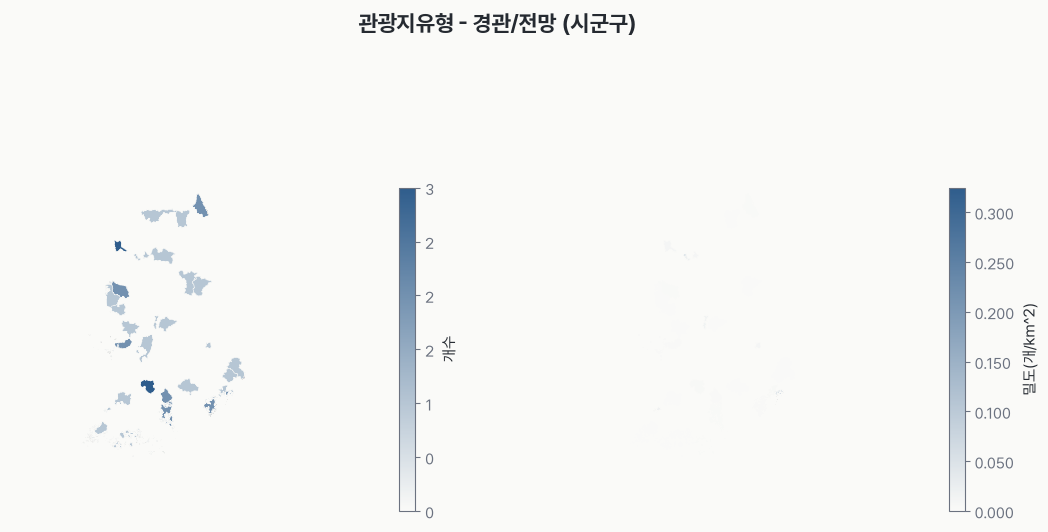

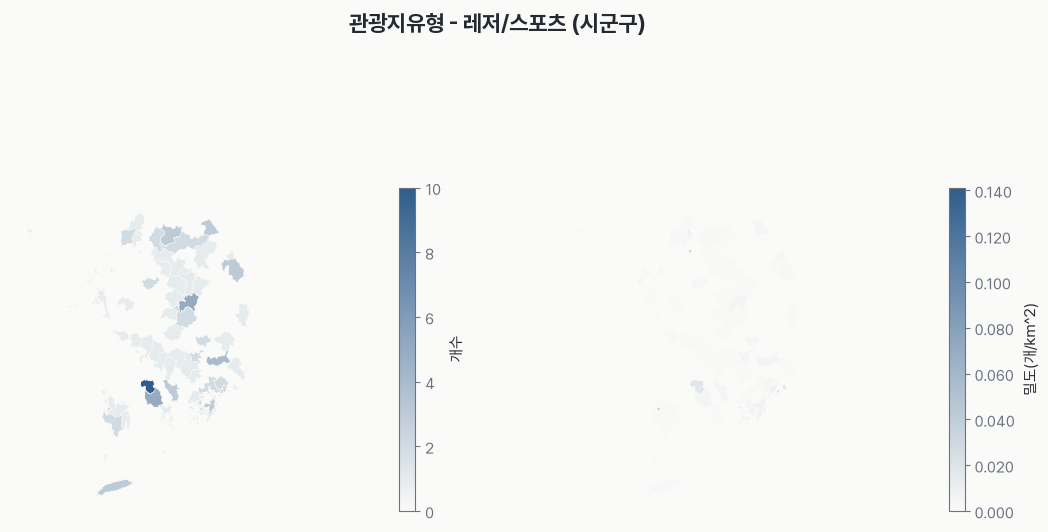

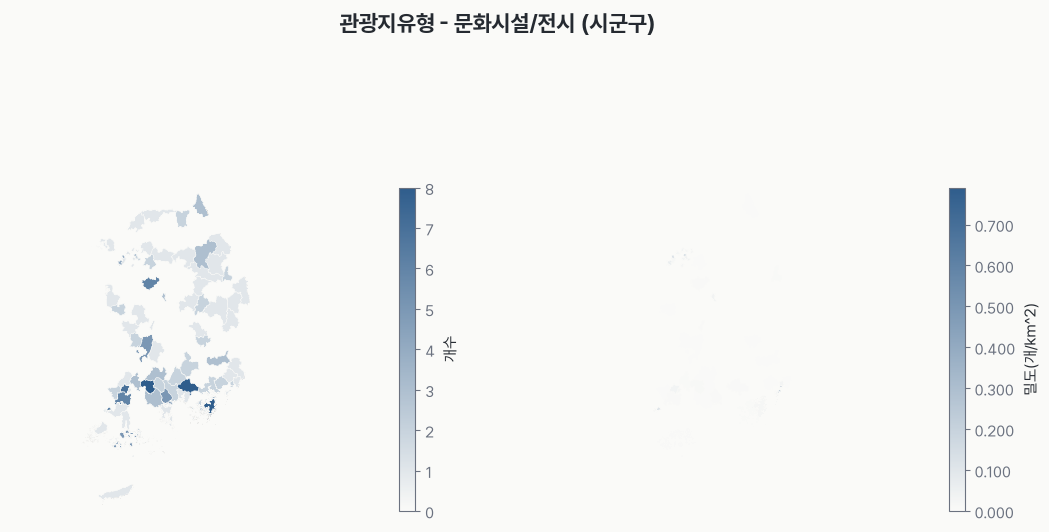

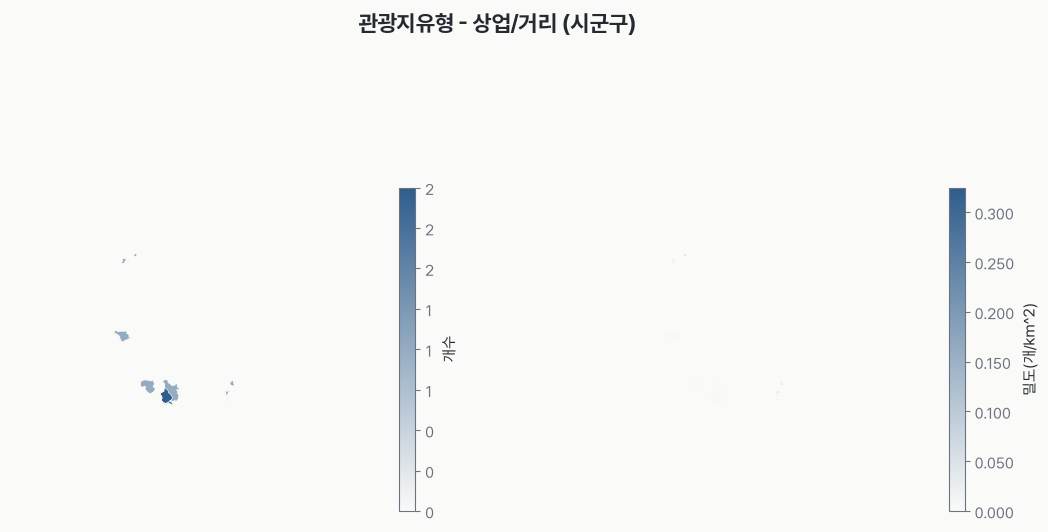

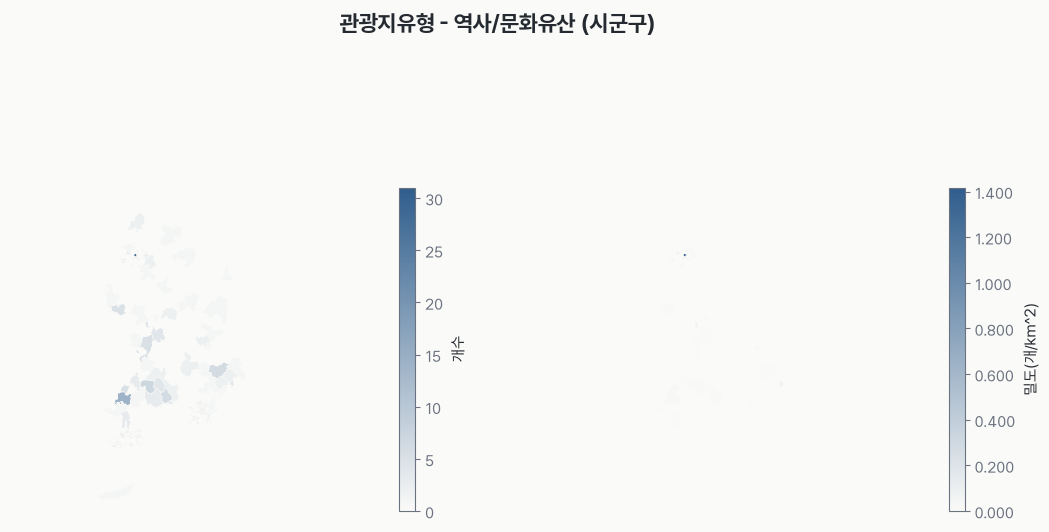

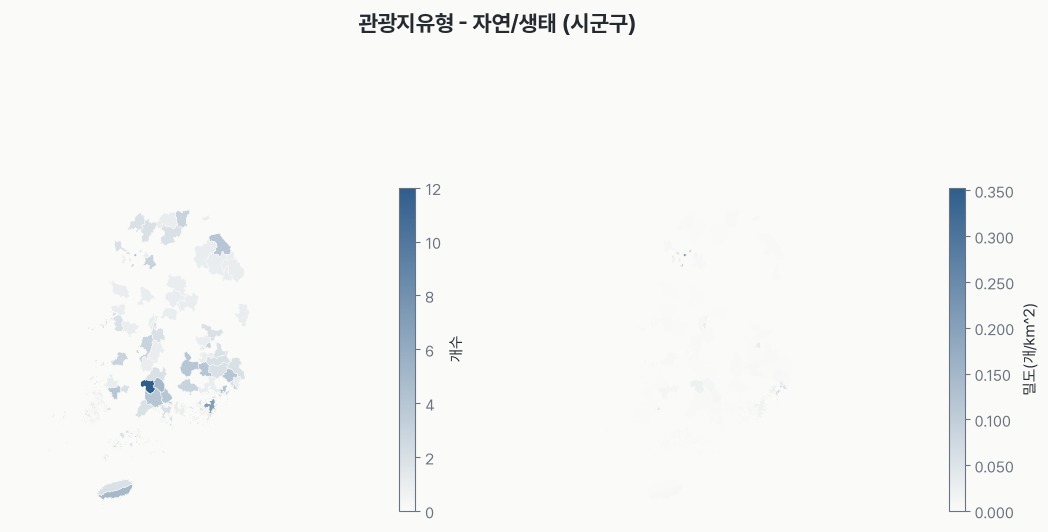

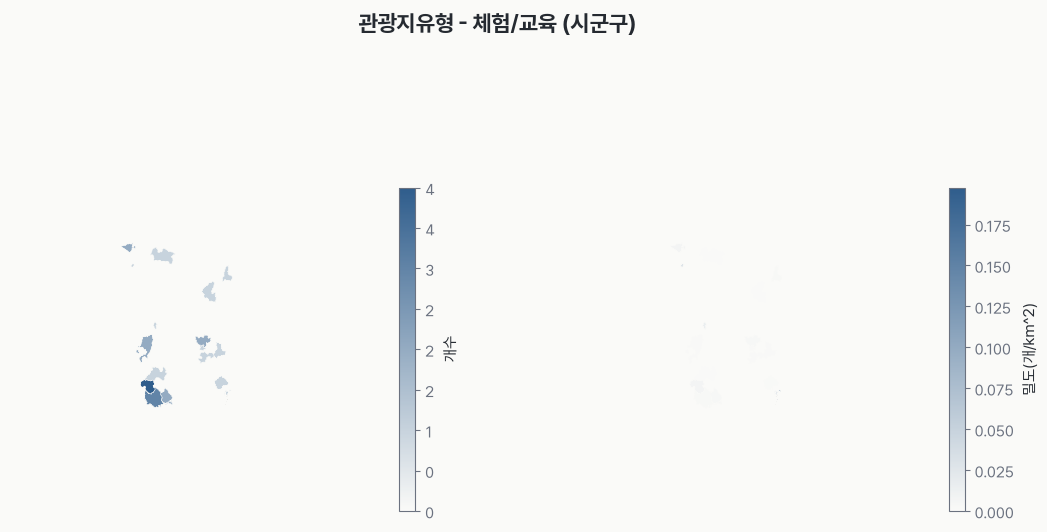

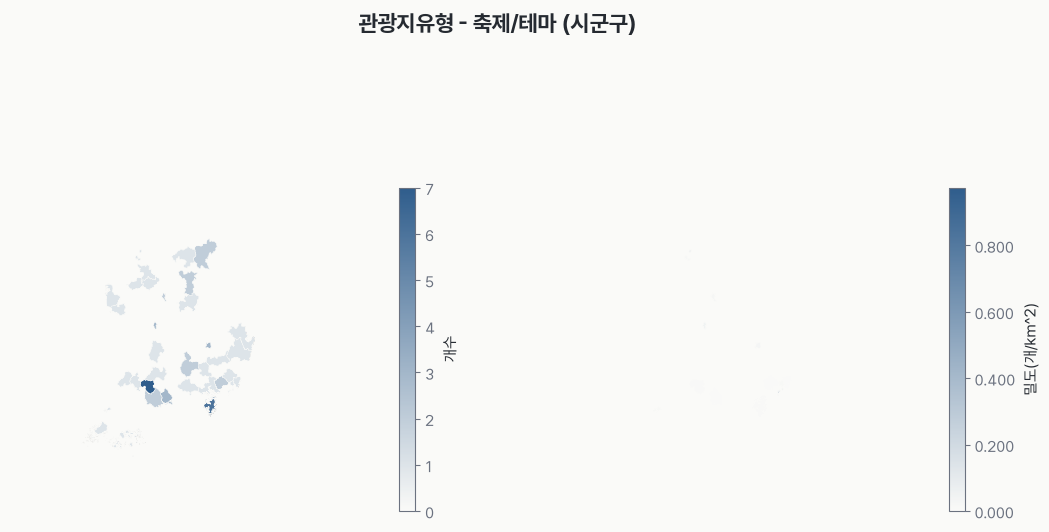

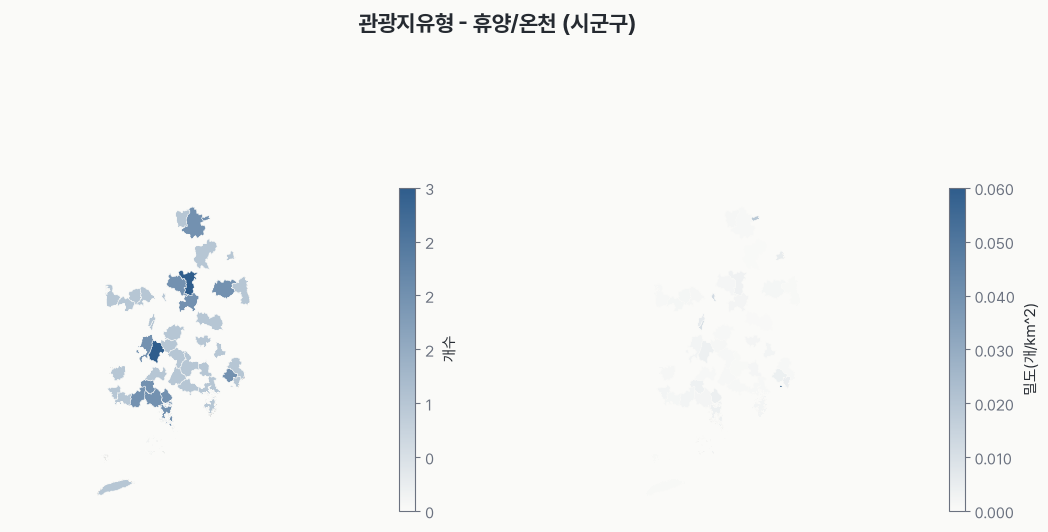

In [15]:
for count_col in tour_count_columns[:-1]:
    tour_type = count_col.replace("관광지수_", "")
    density_col = f"관광지밀도_{tour_type}"
    plot_count_density_pair(count_col, density_col, f"관광지유형 - {tour_type}")

### 13-2. 관광지 총개수·총밀도

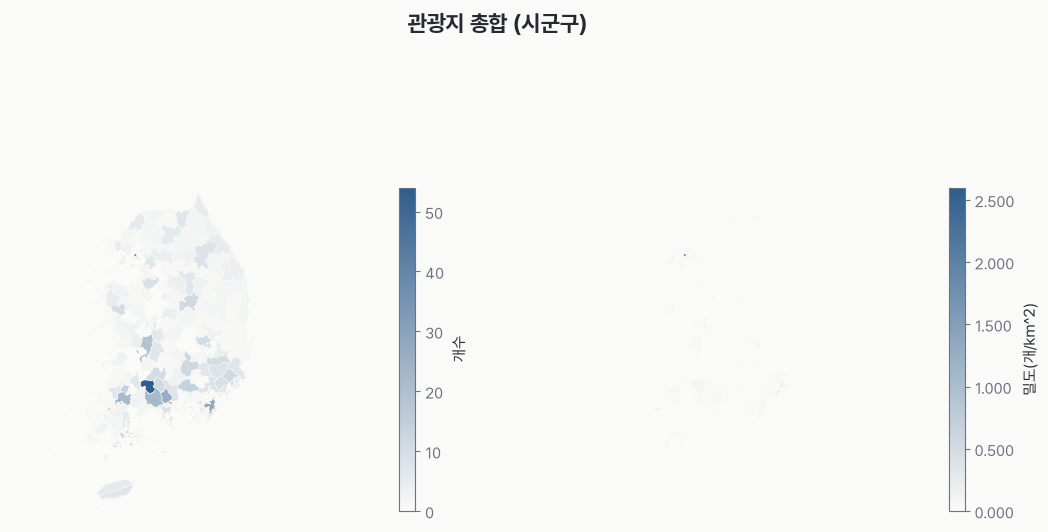

In [16]:
plot_count_density_pair("관광지수_총합", "관광지밀도_총합", "관광지 총합")

### 13-3. 상권업종 중분류별 개수·밀도(75종)

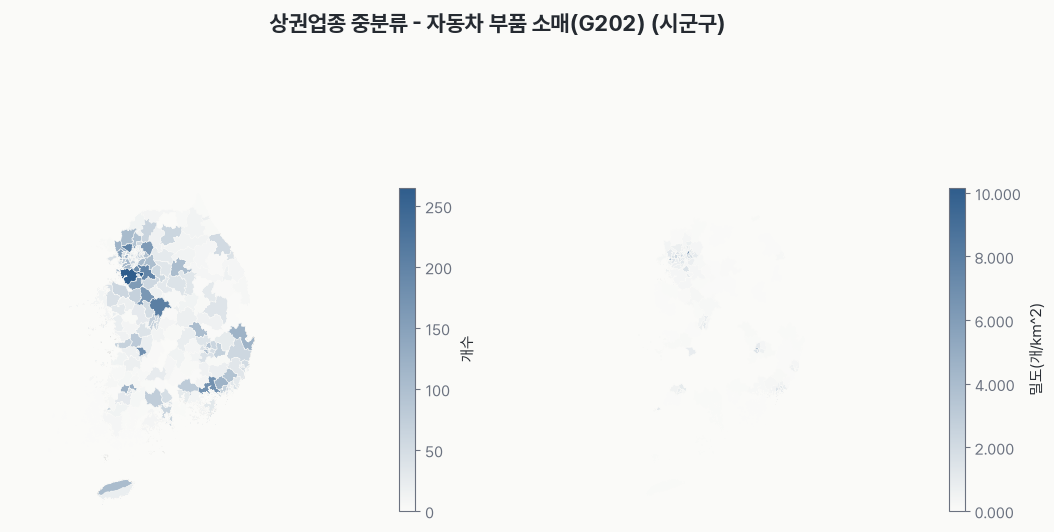

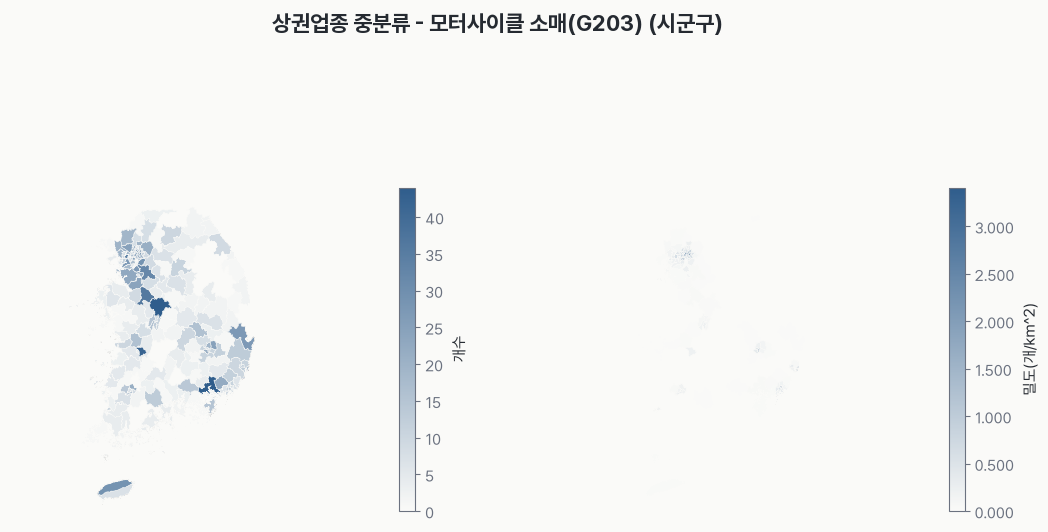

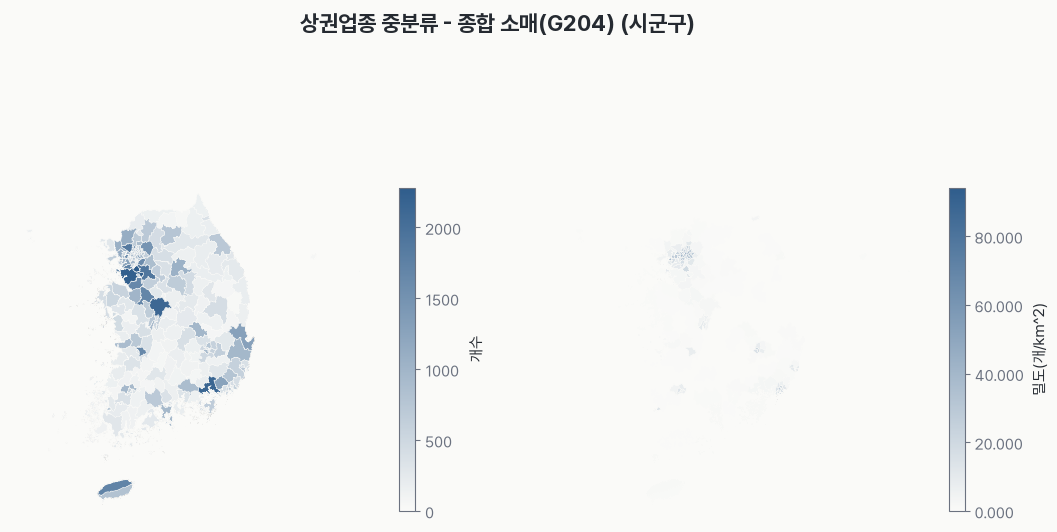

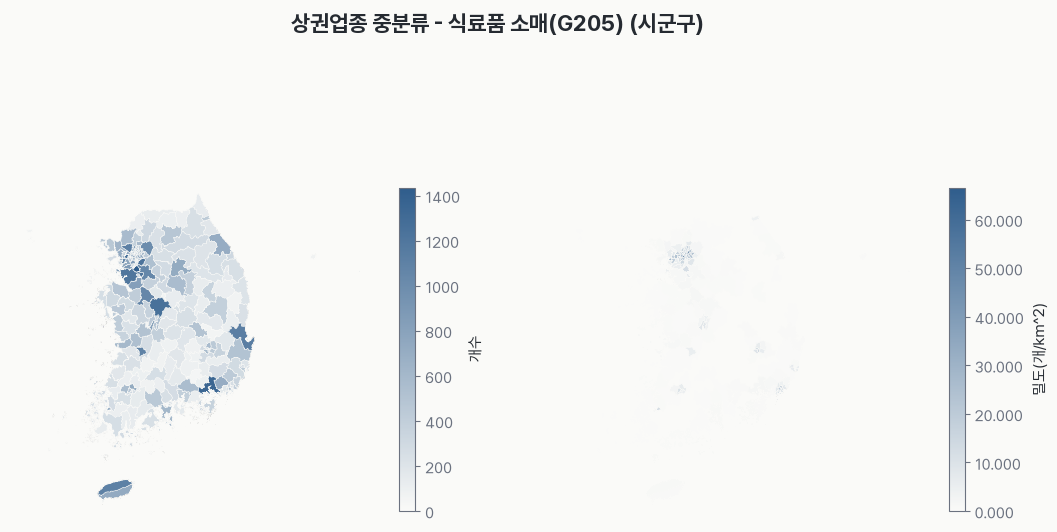

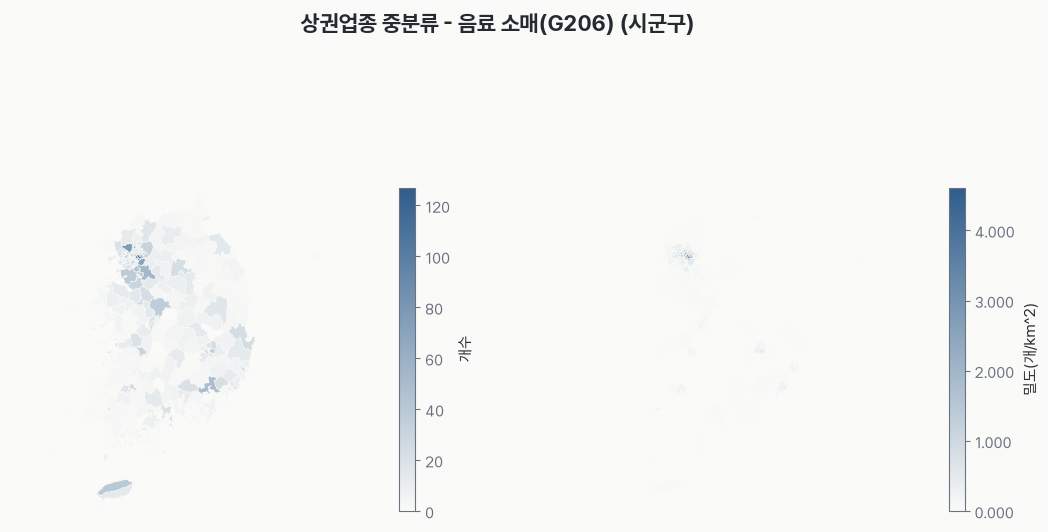

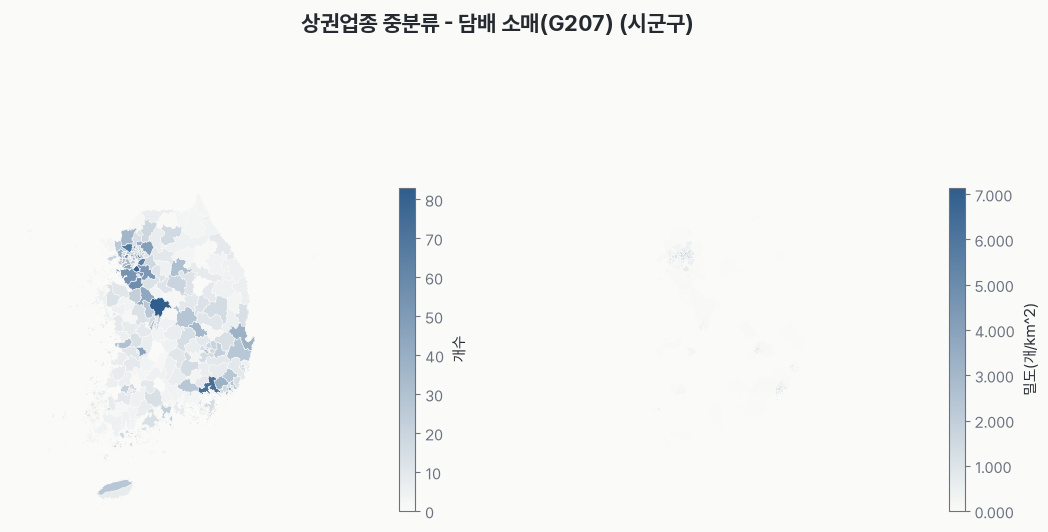

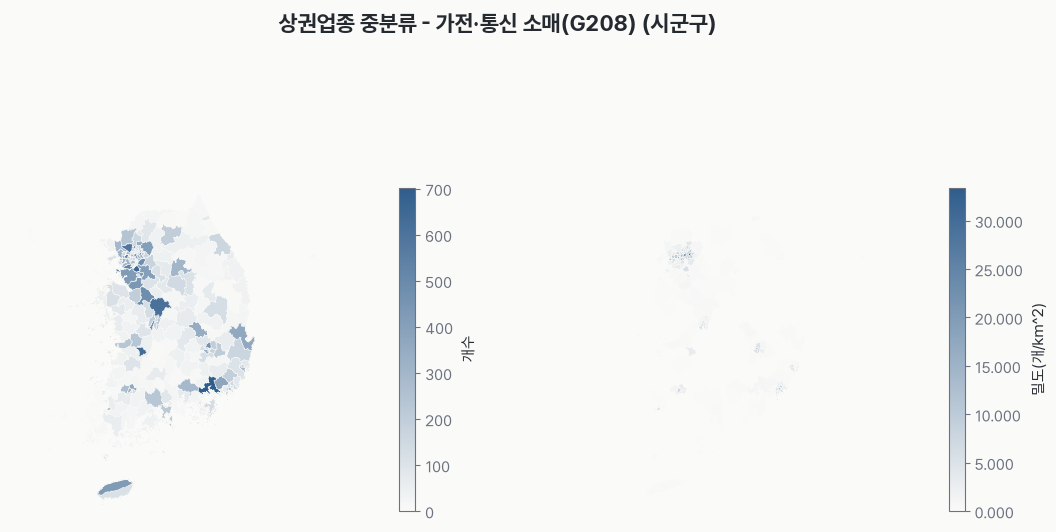

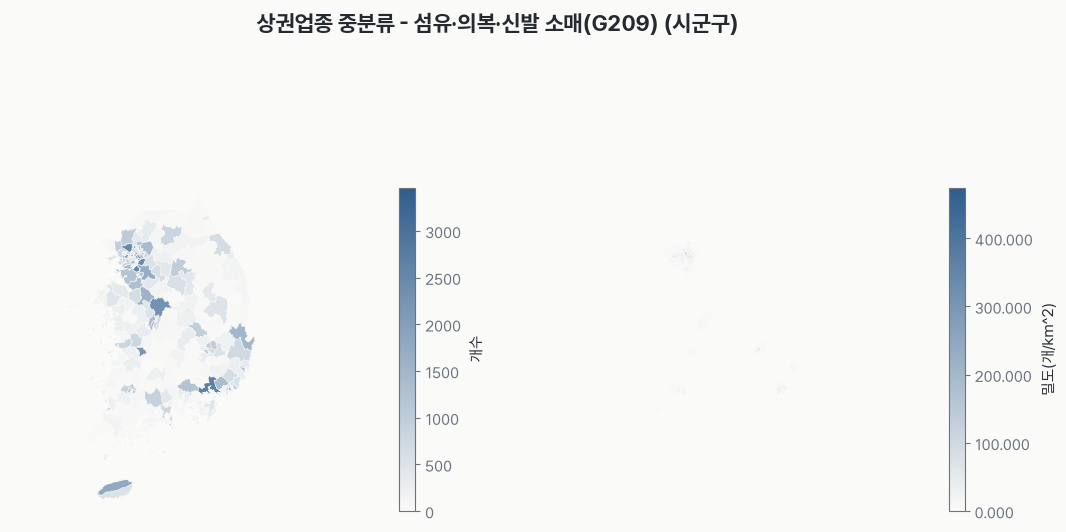

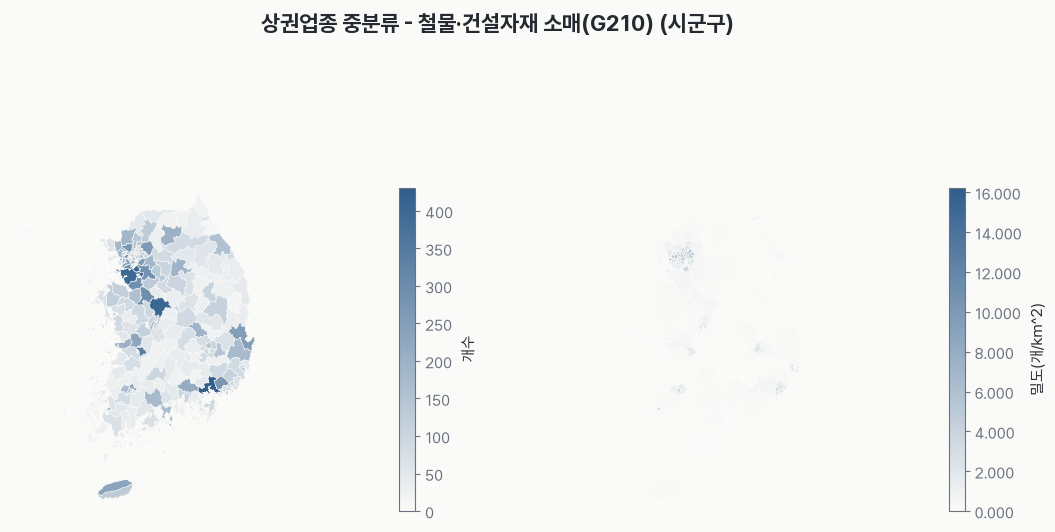

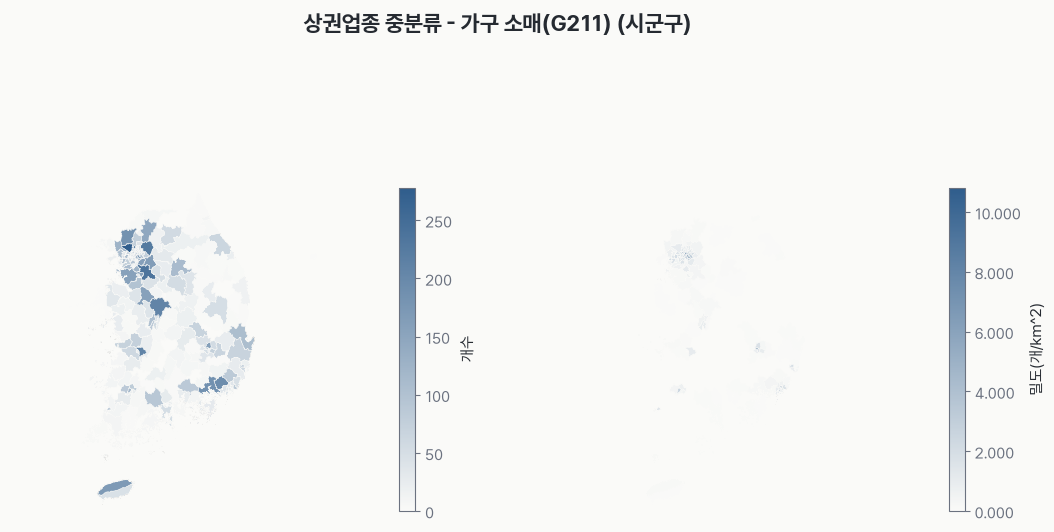

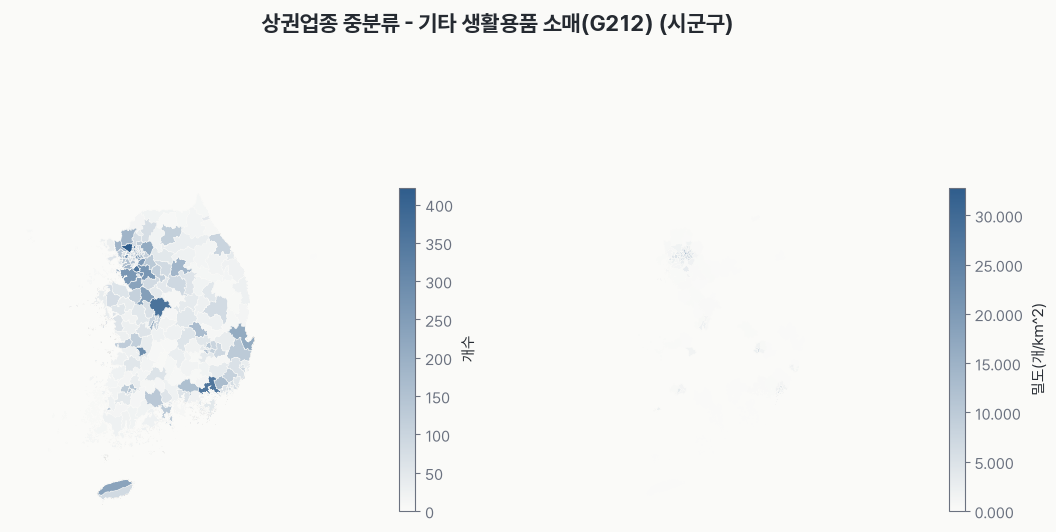

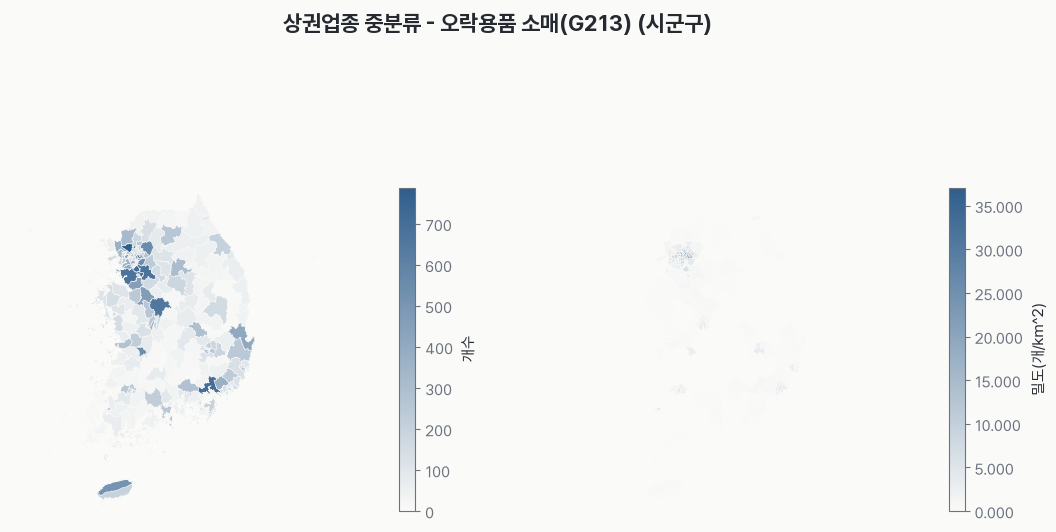

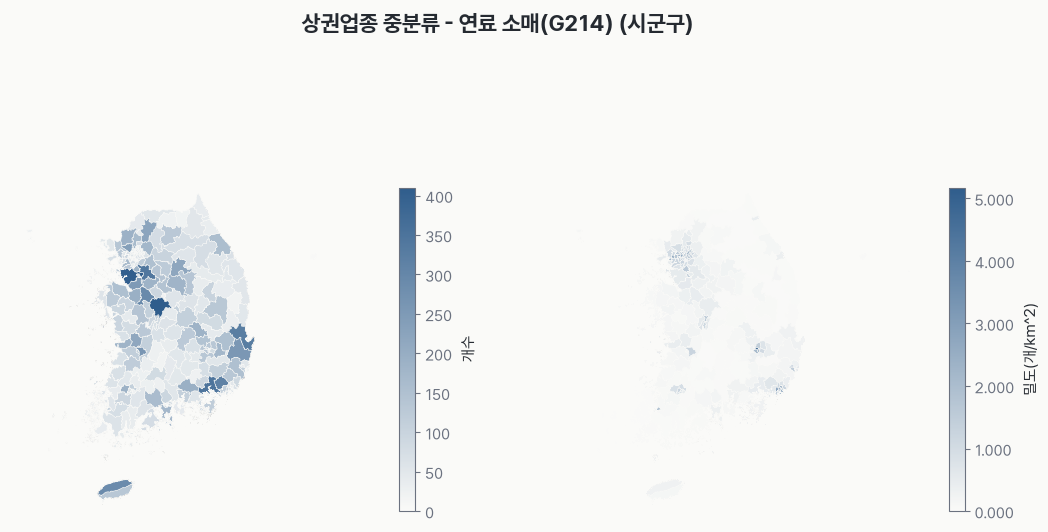

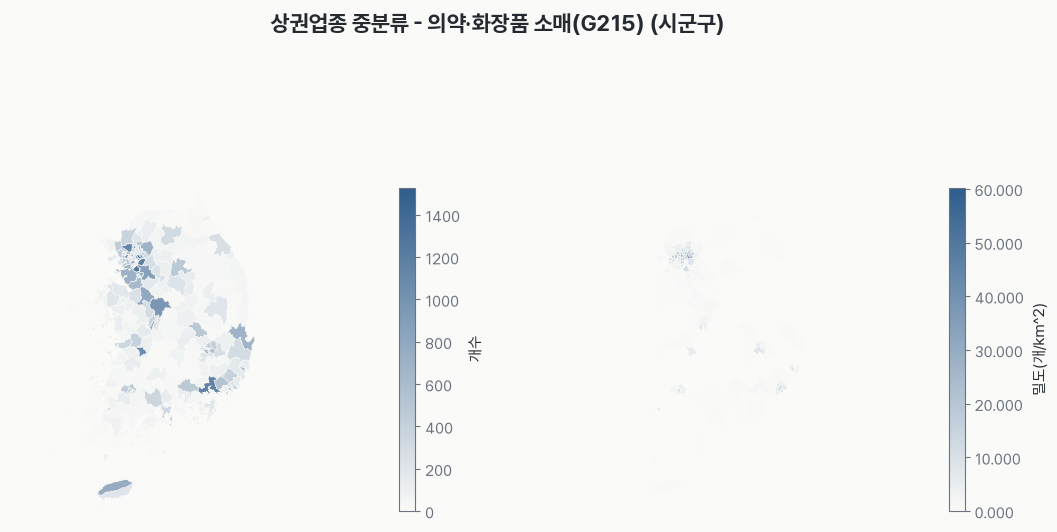

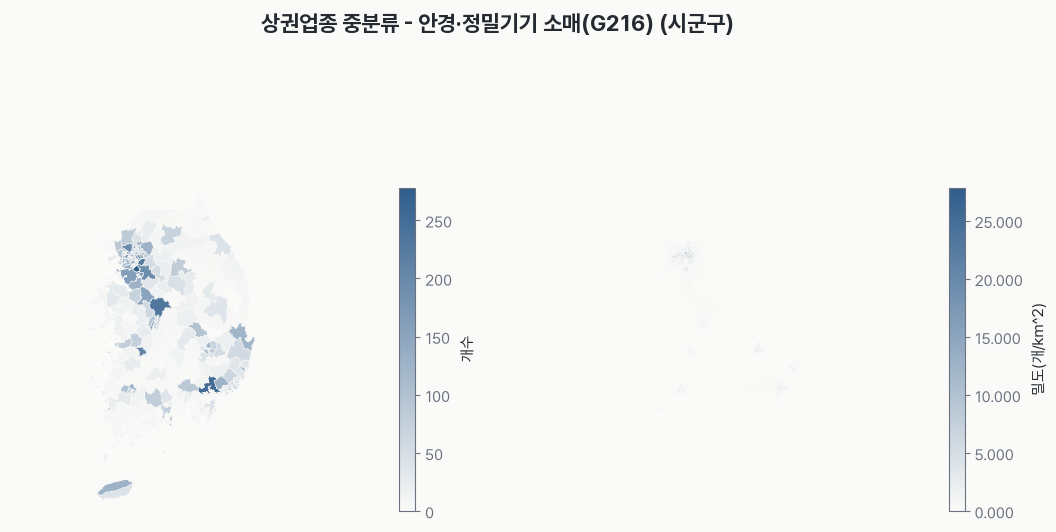

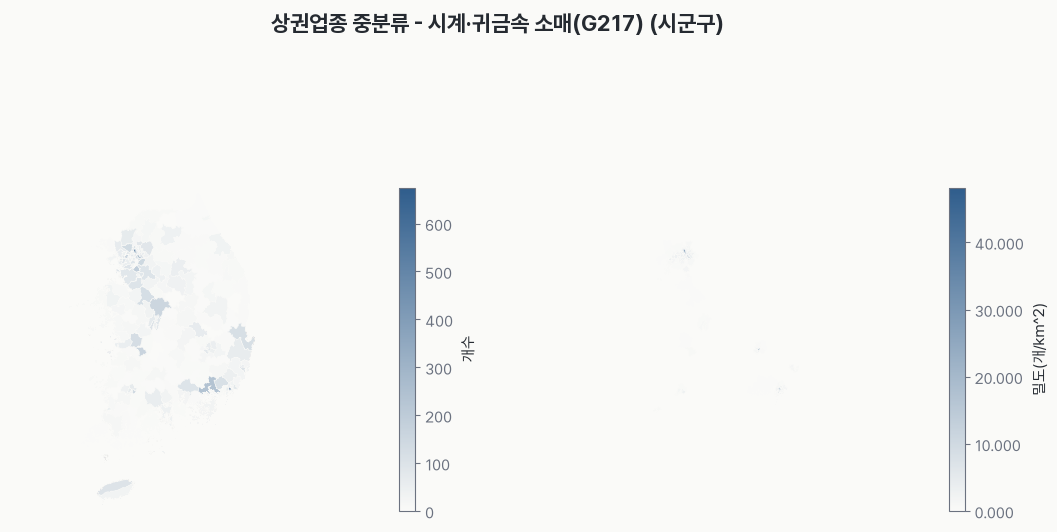

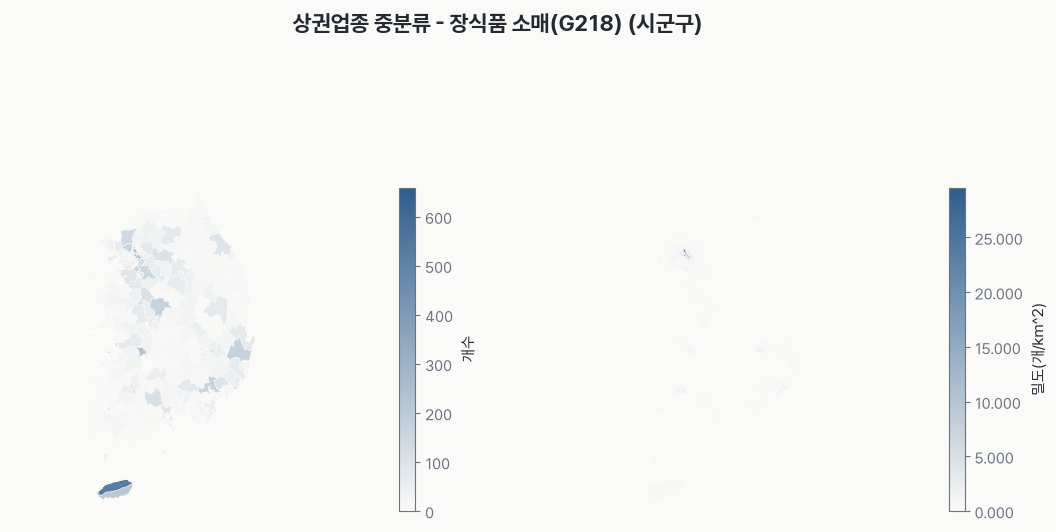

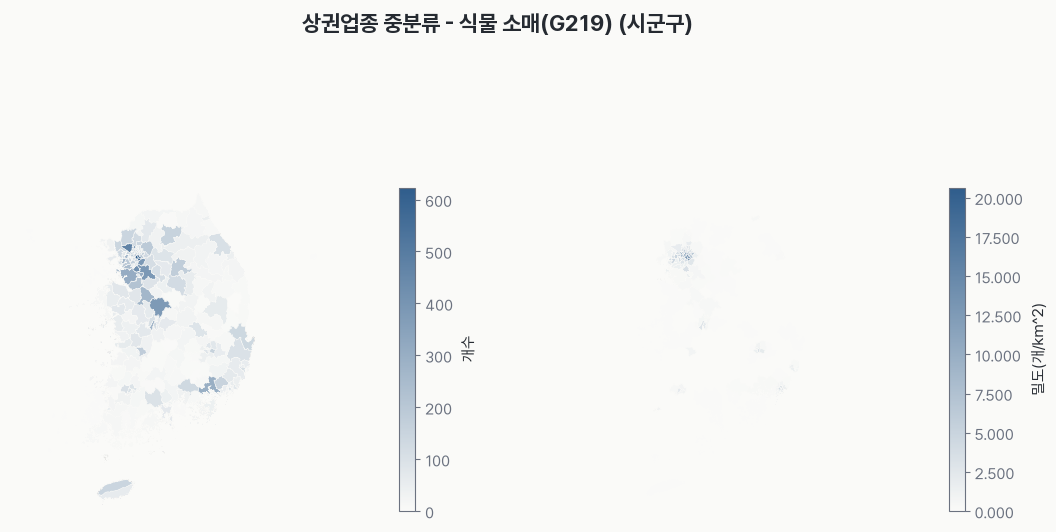

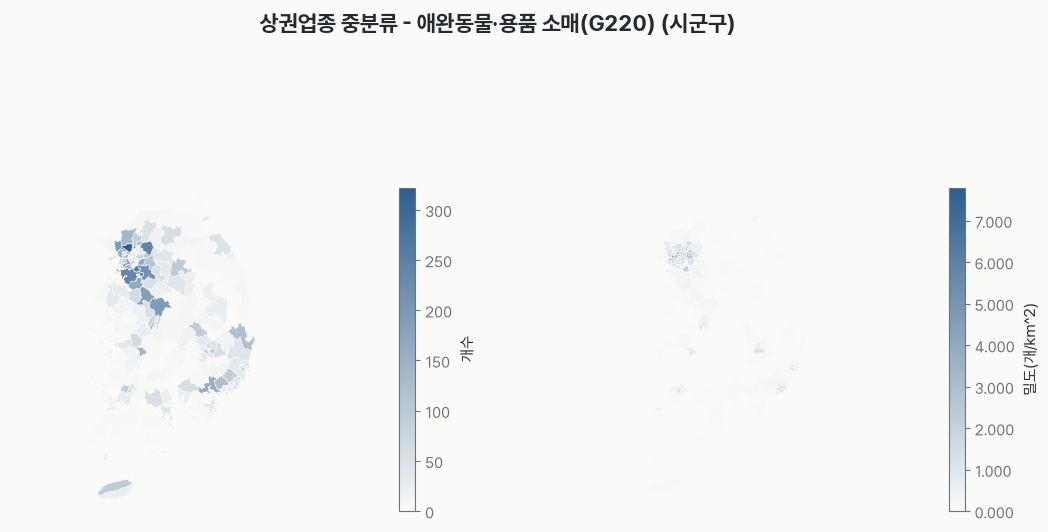

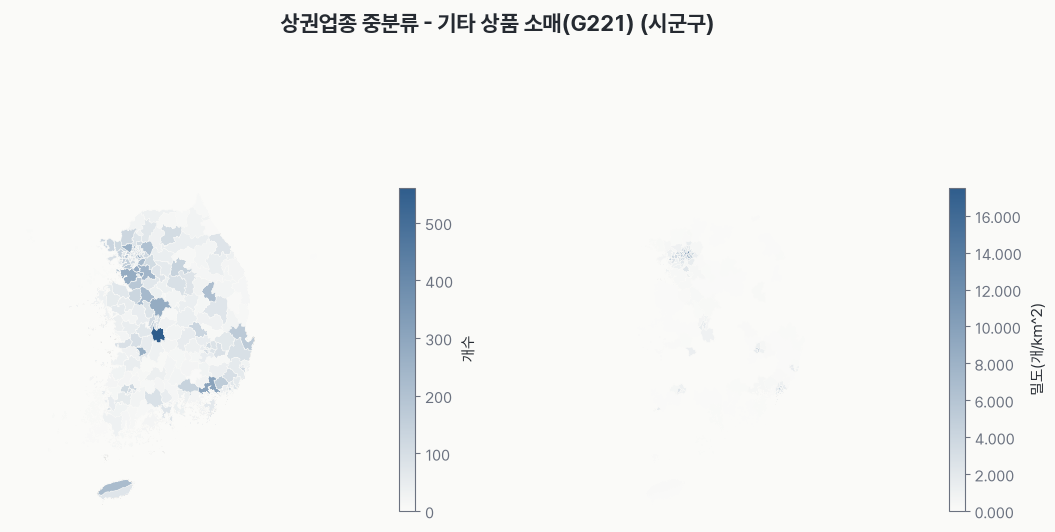

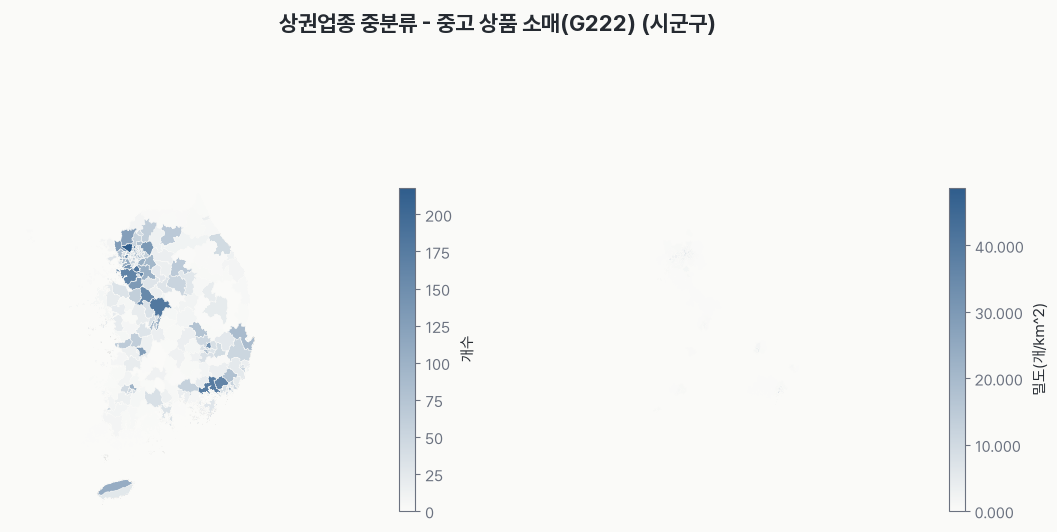

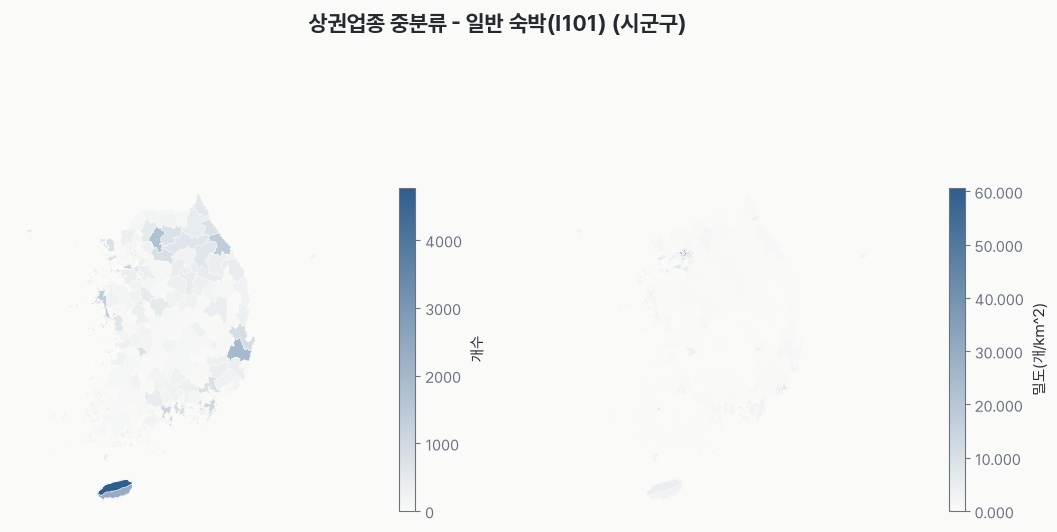

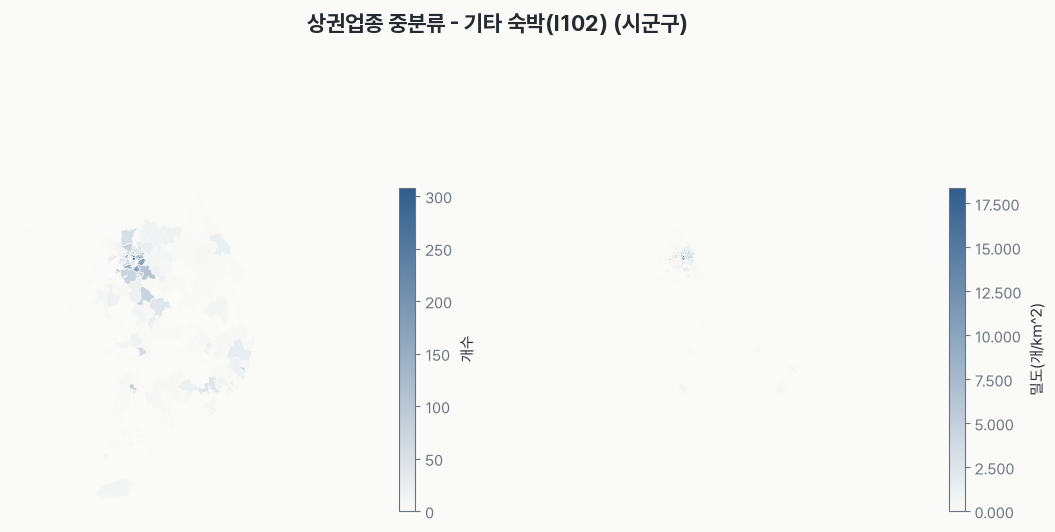

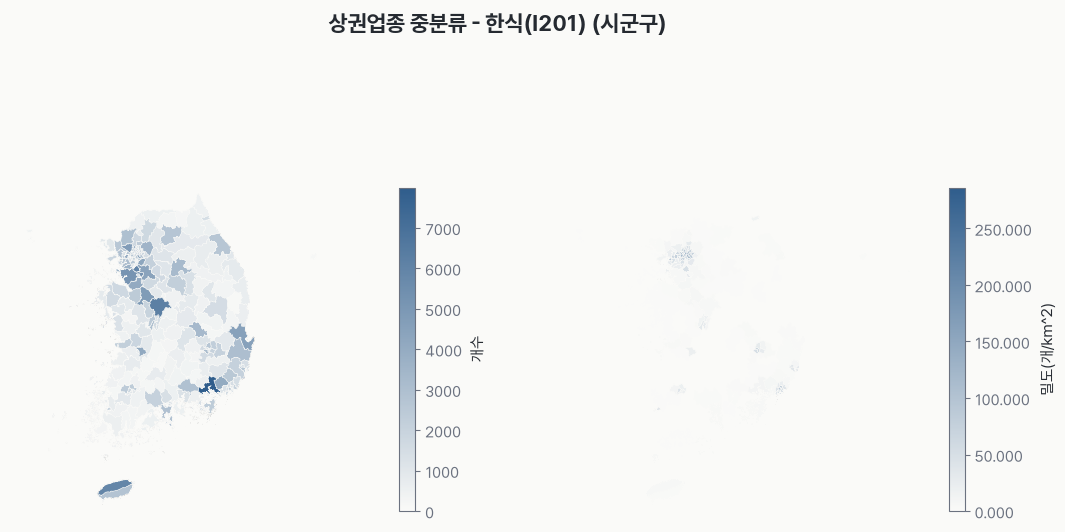

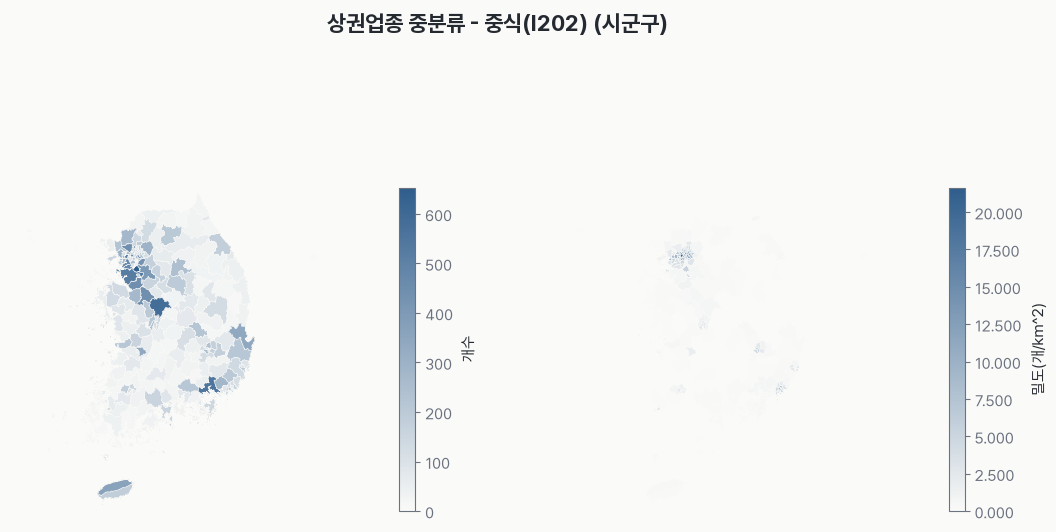

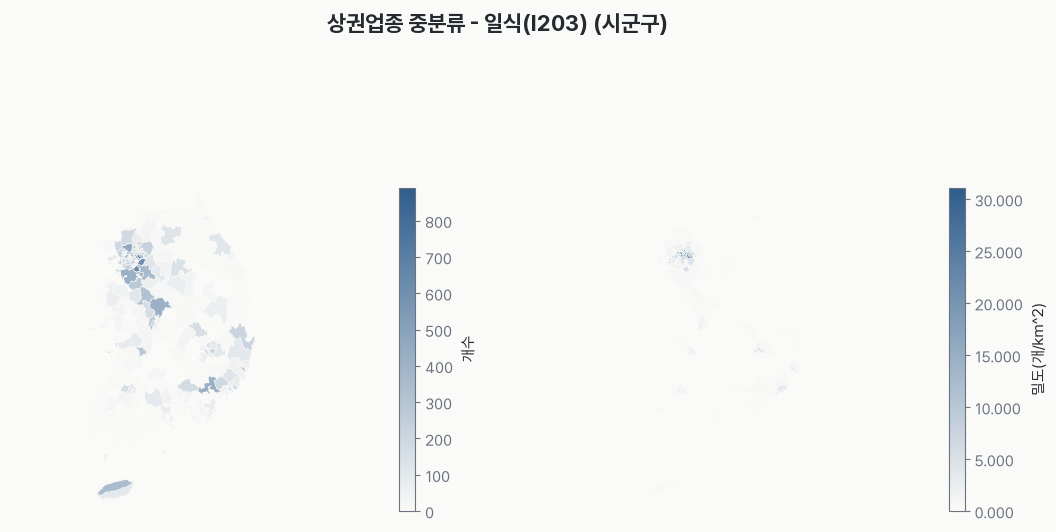

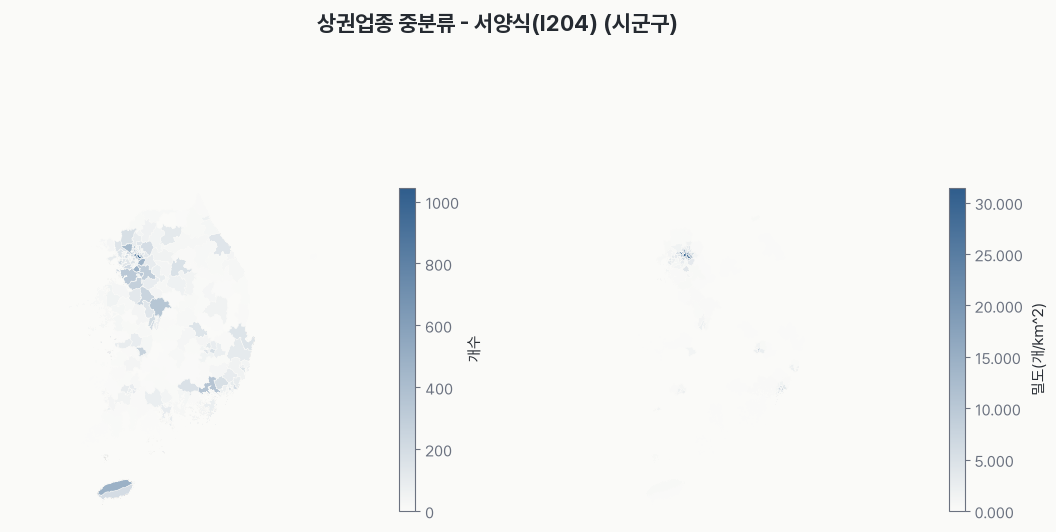

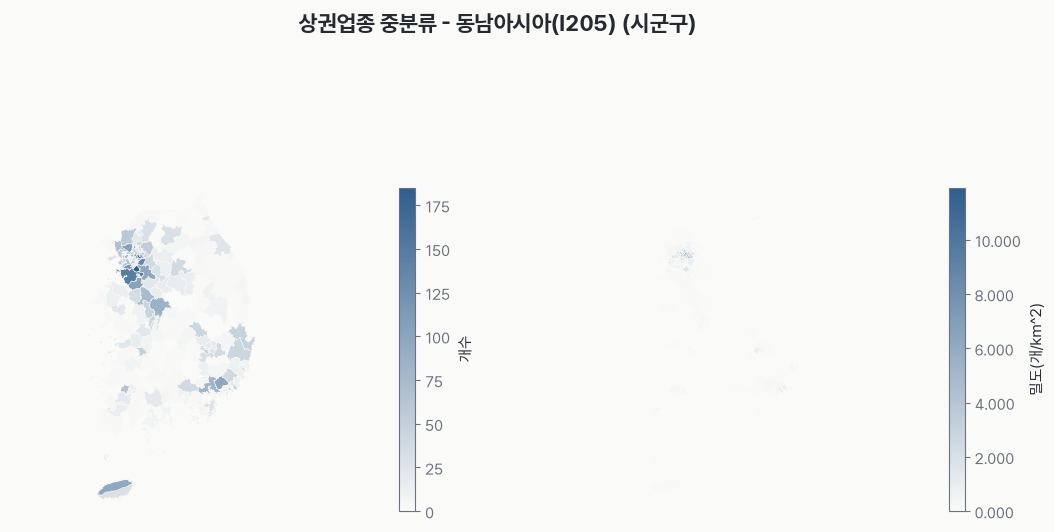

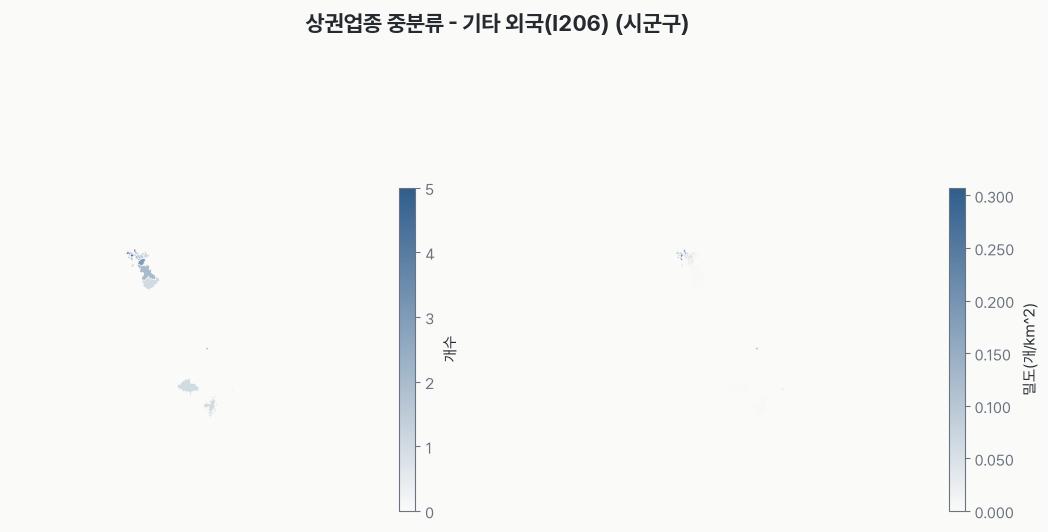

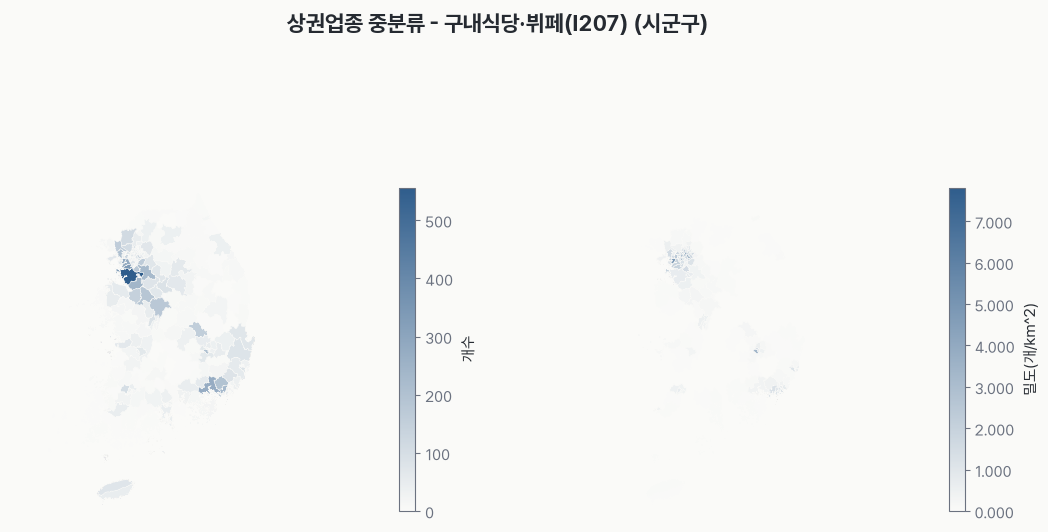

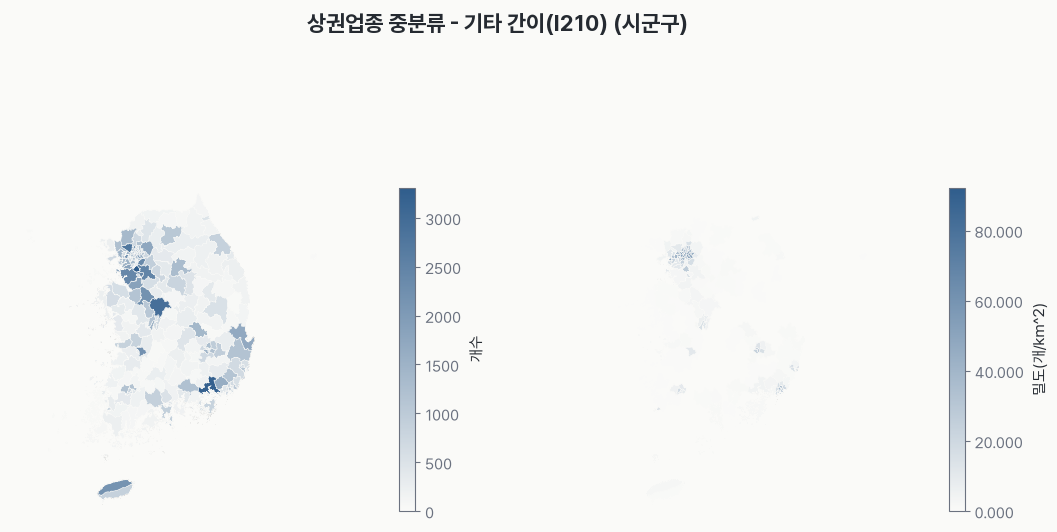

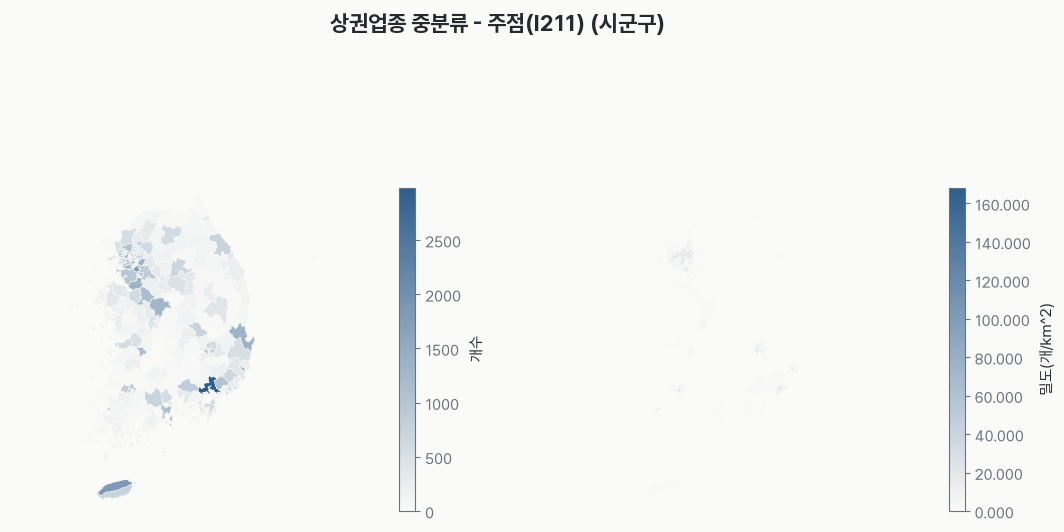

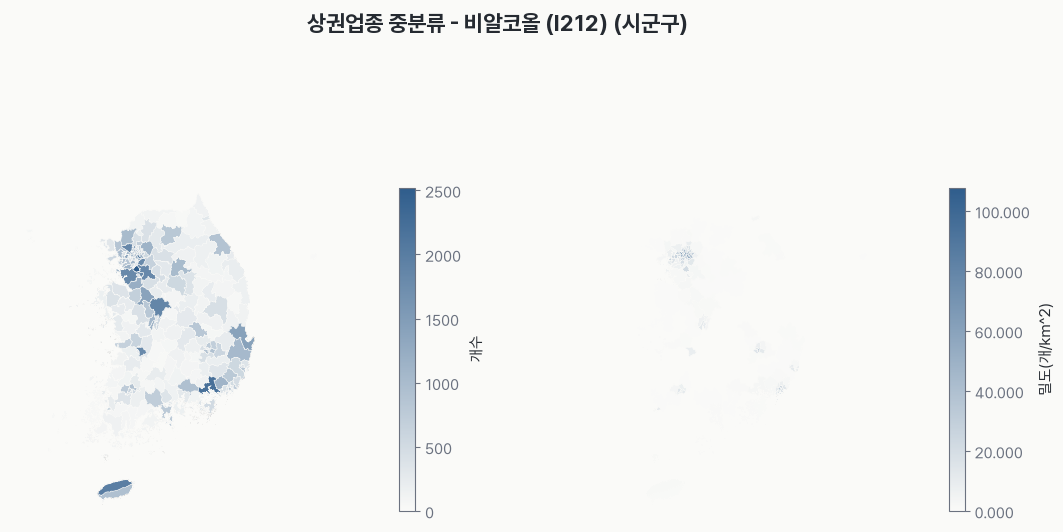

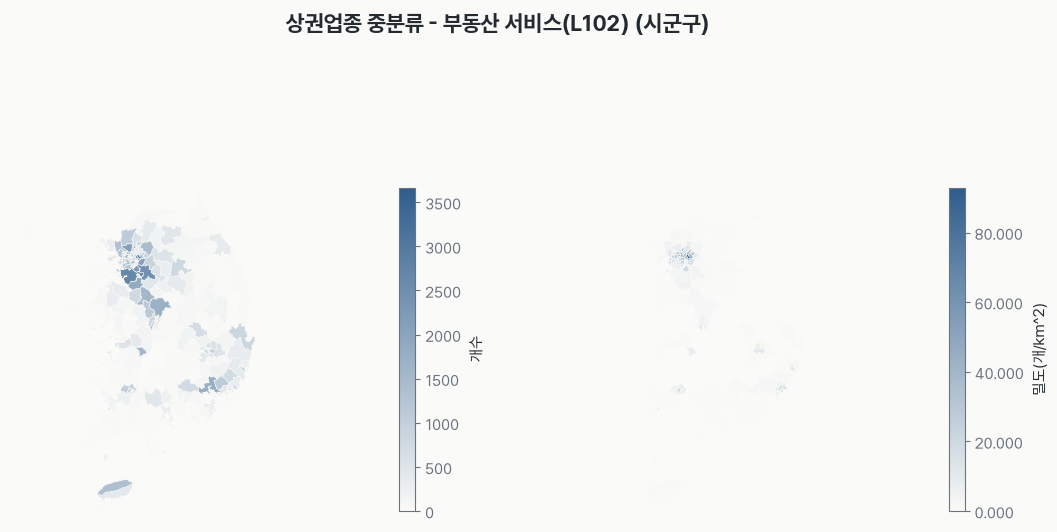

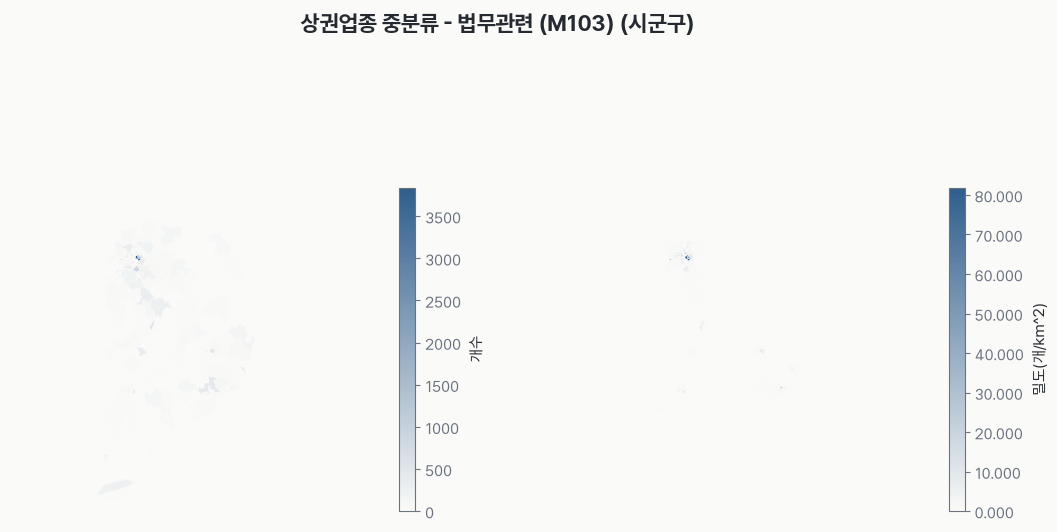

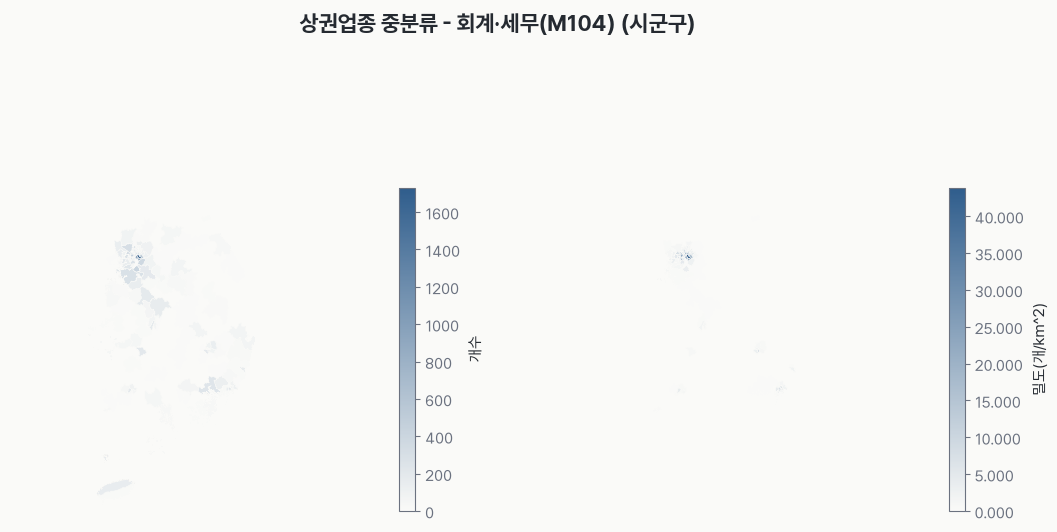

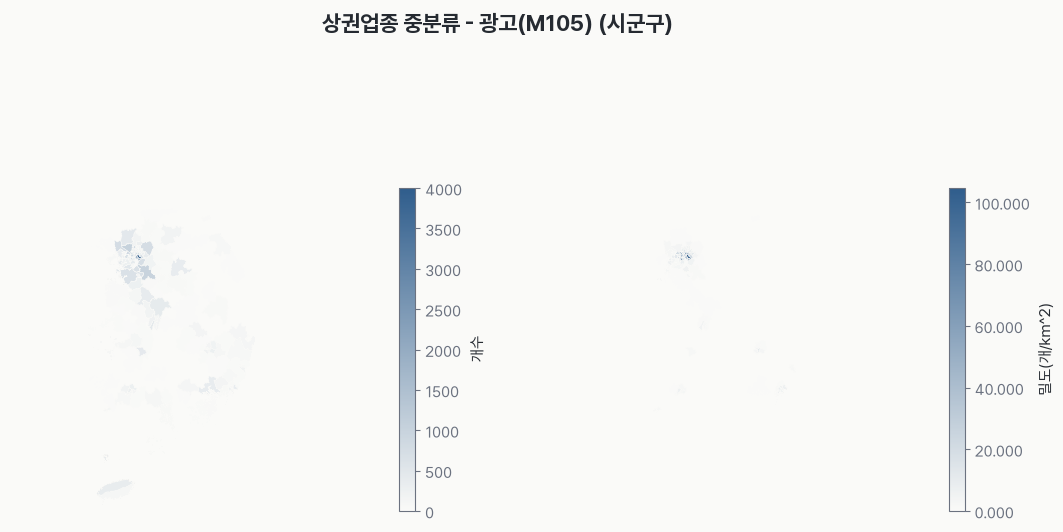

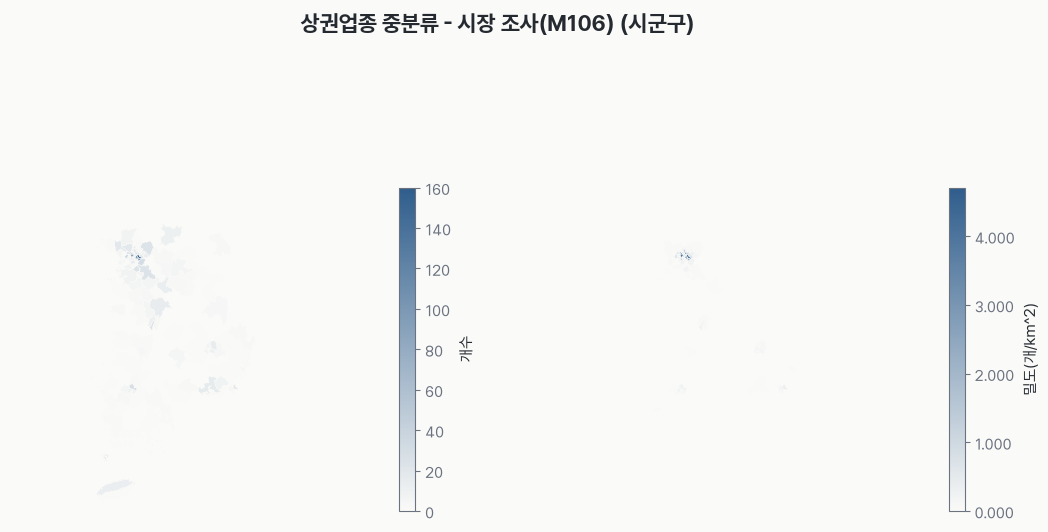

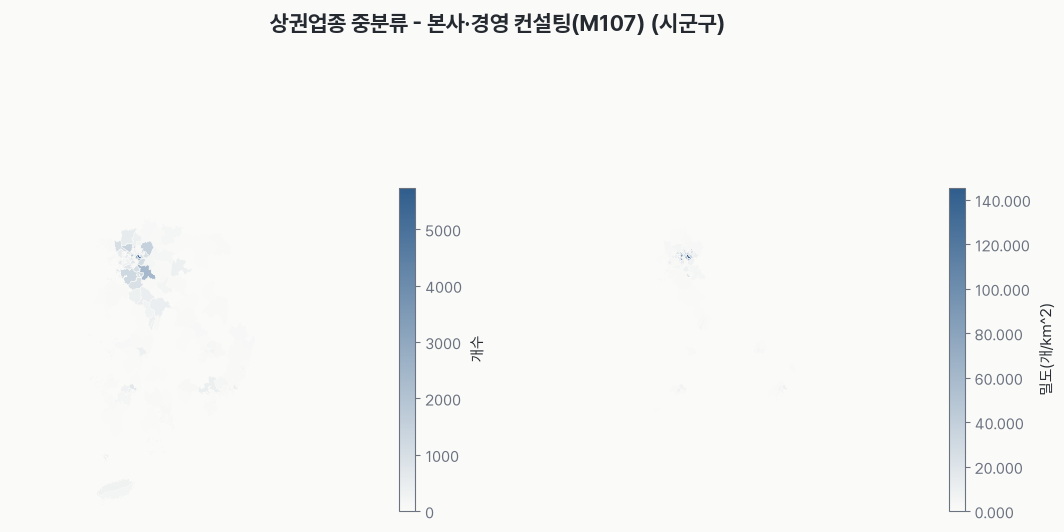

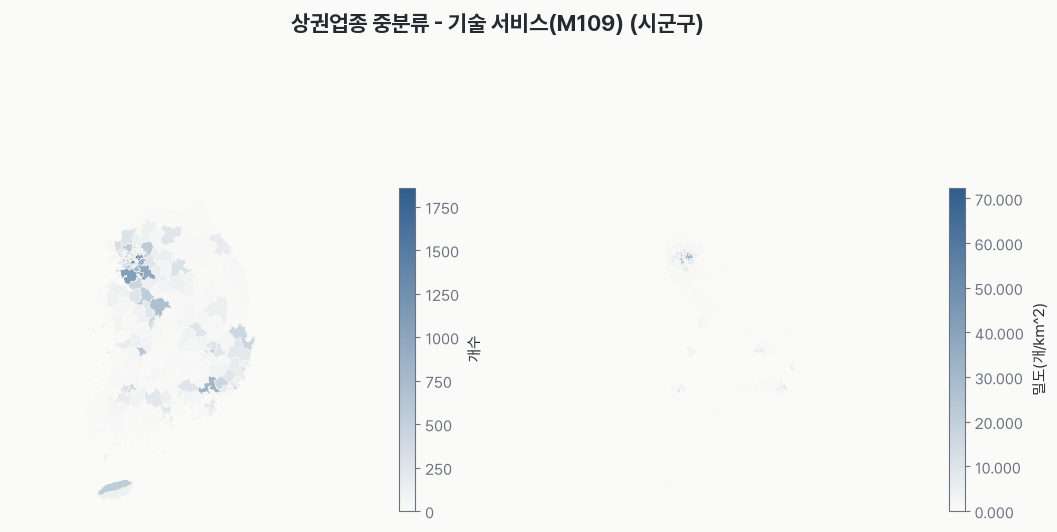

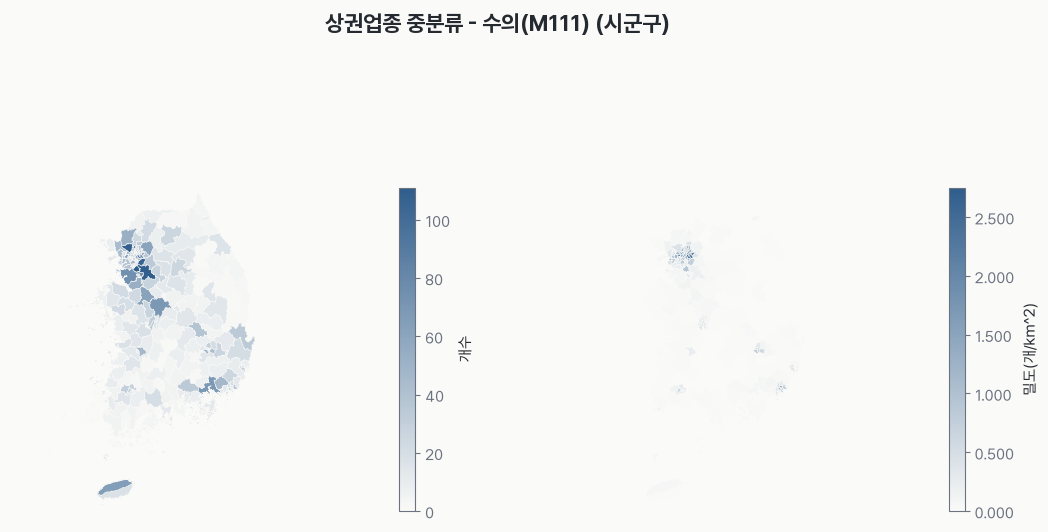

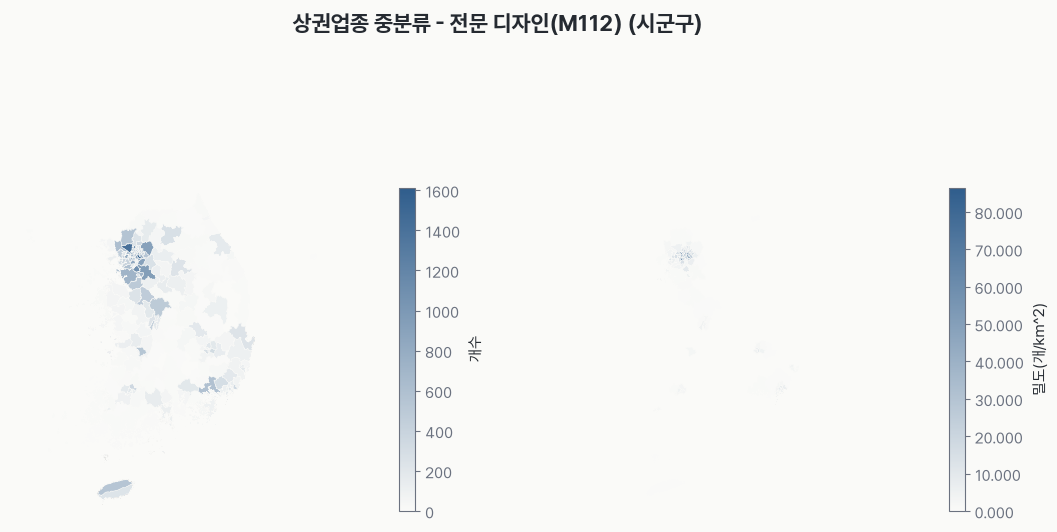

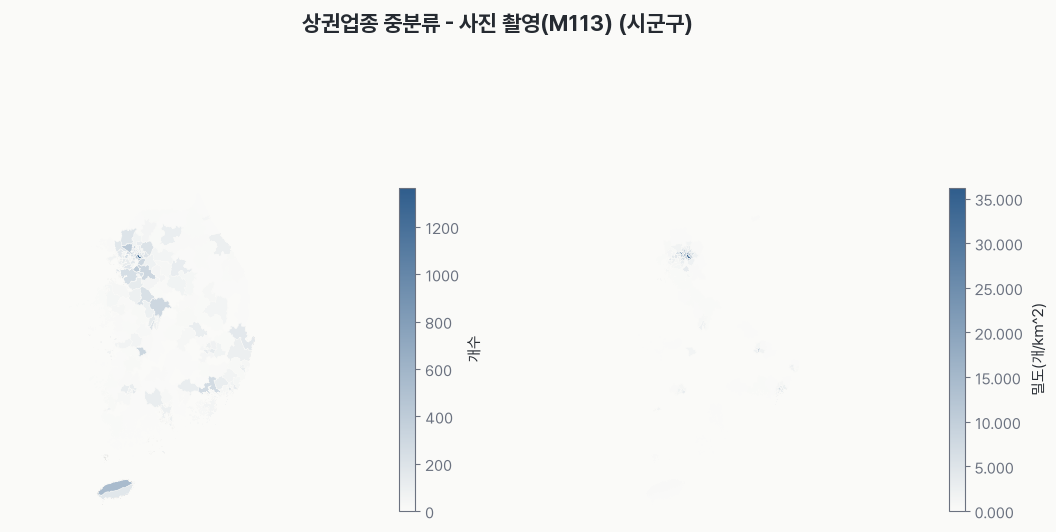

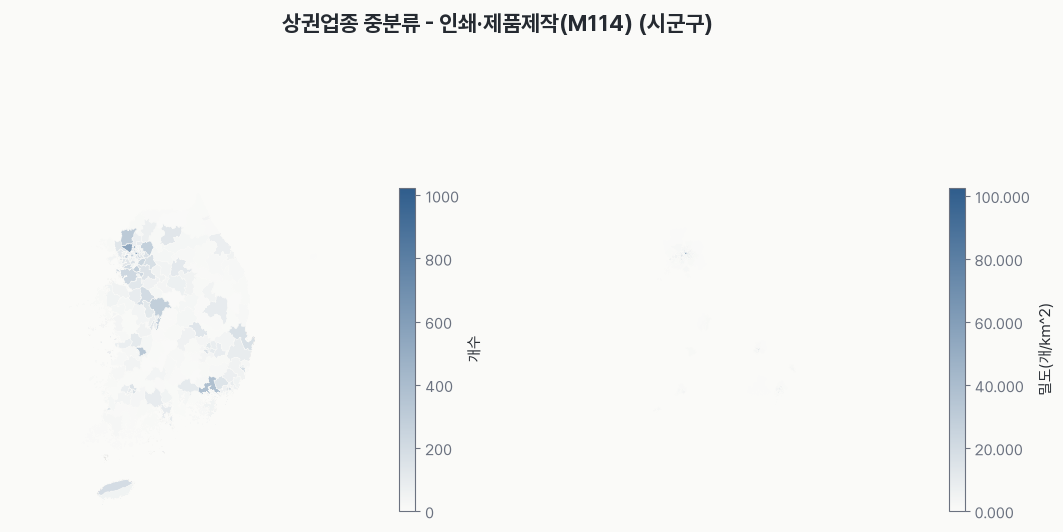

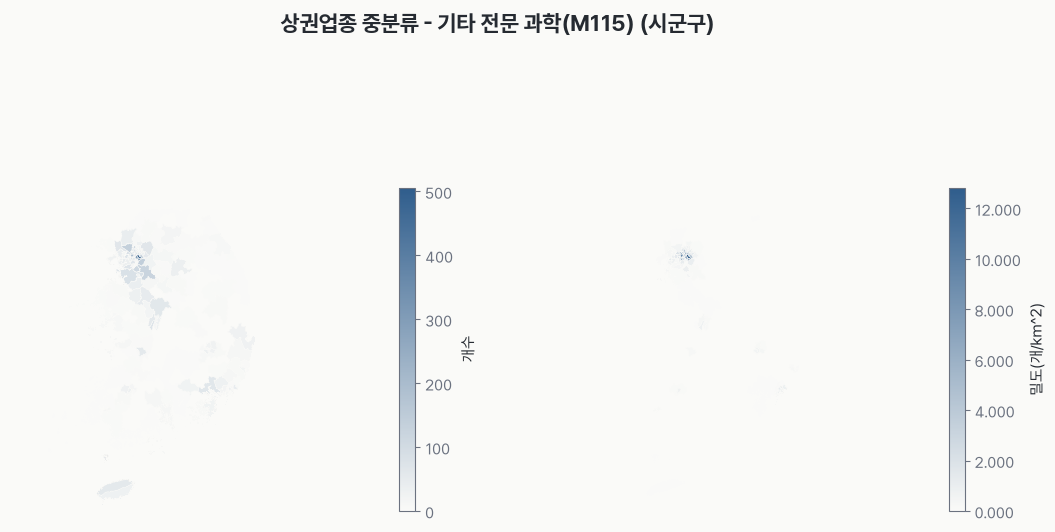

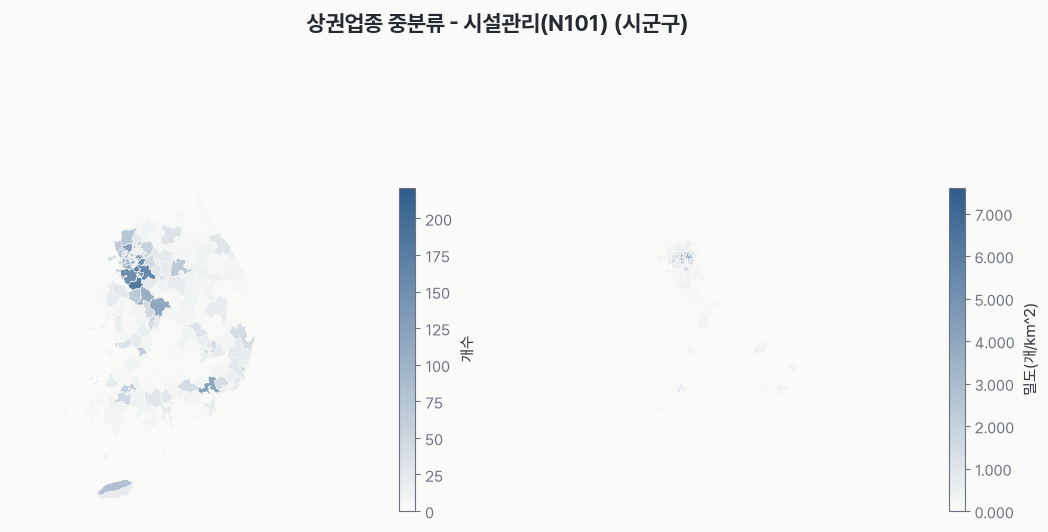

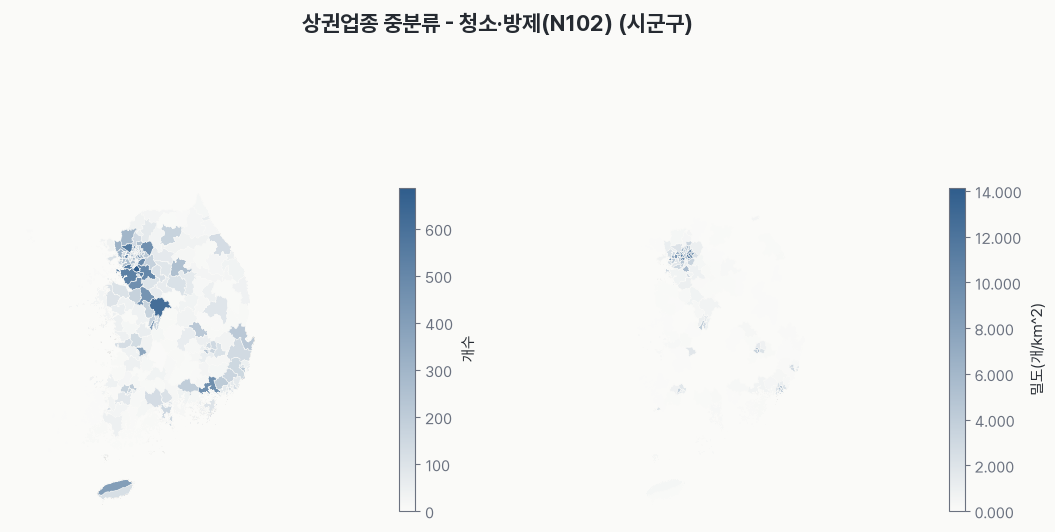

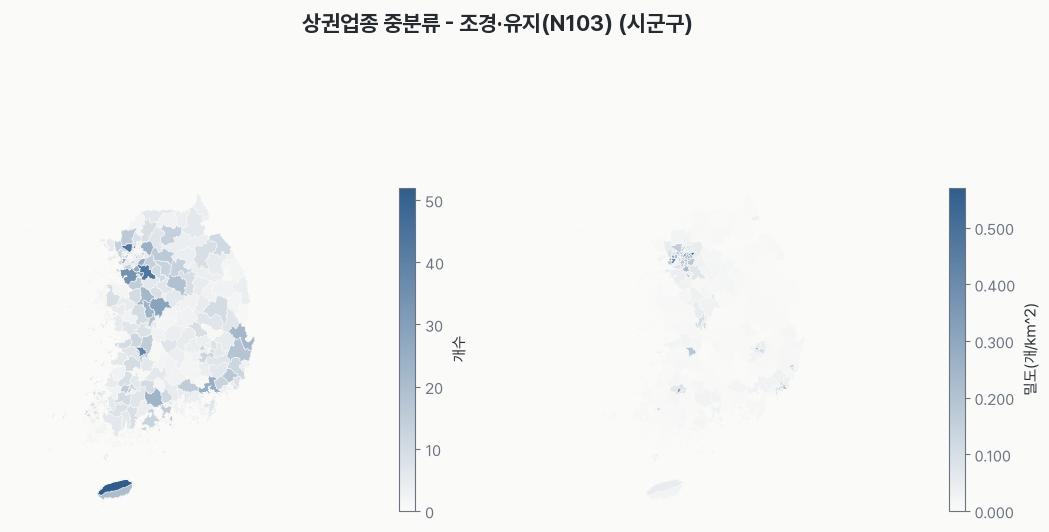

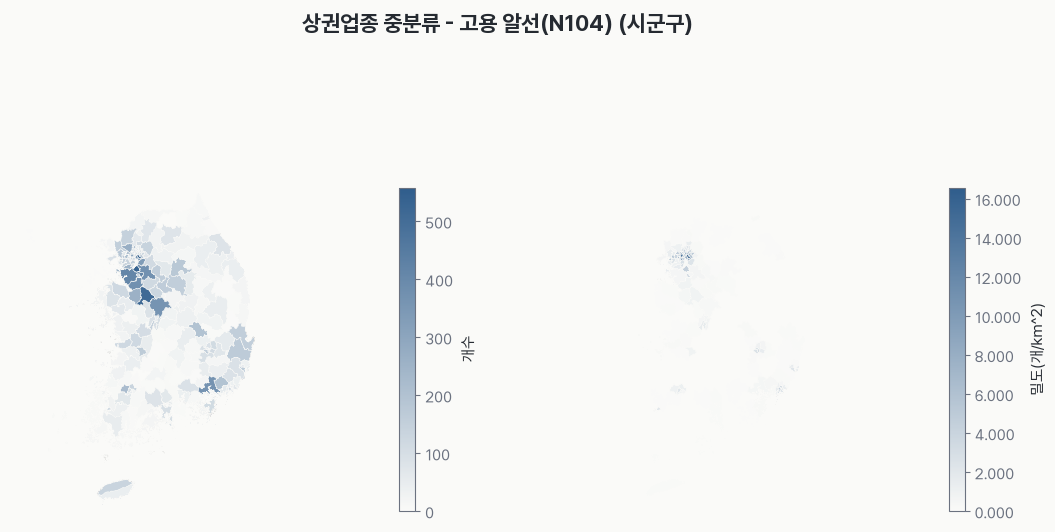

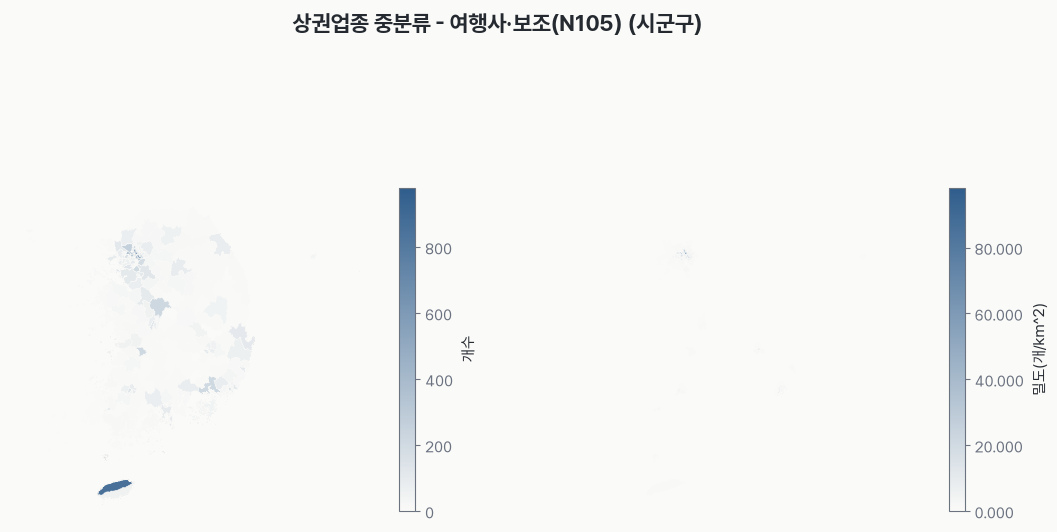

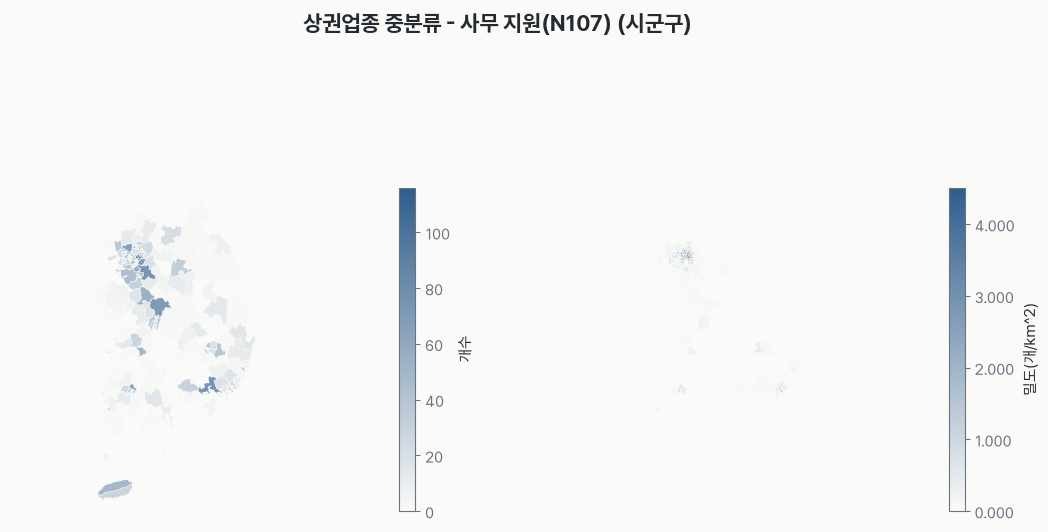

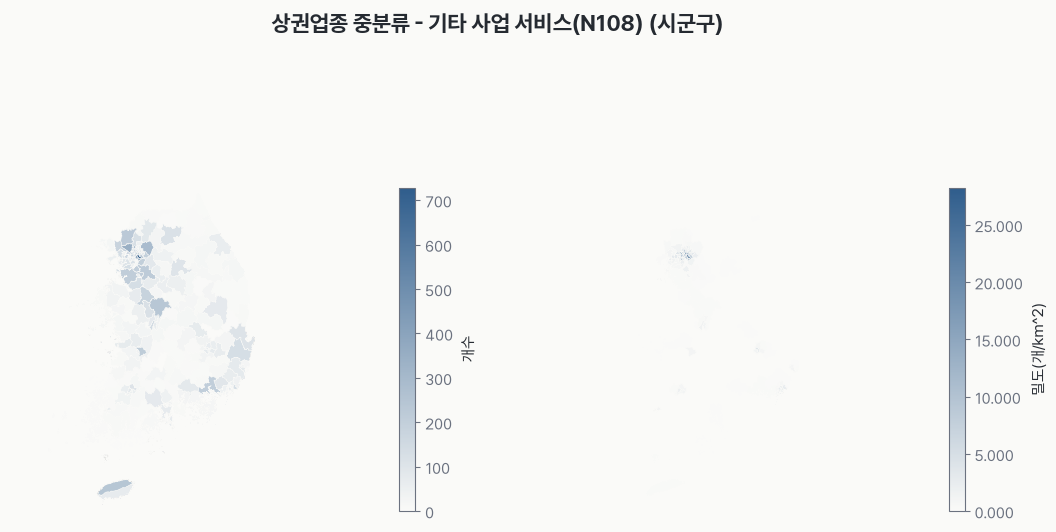

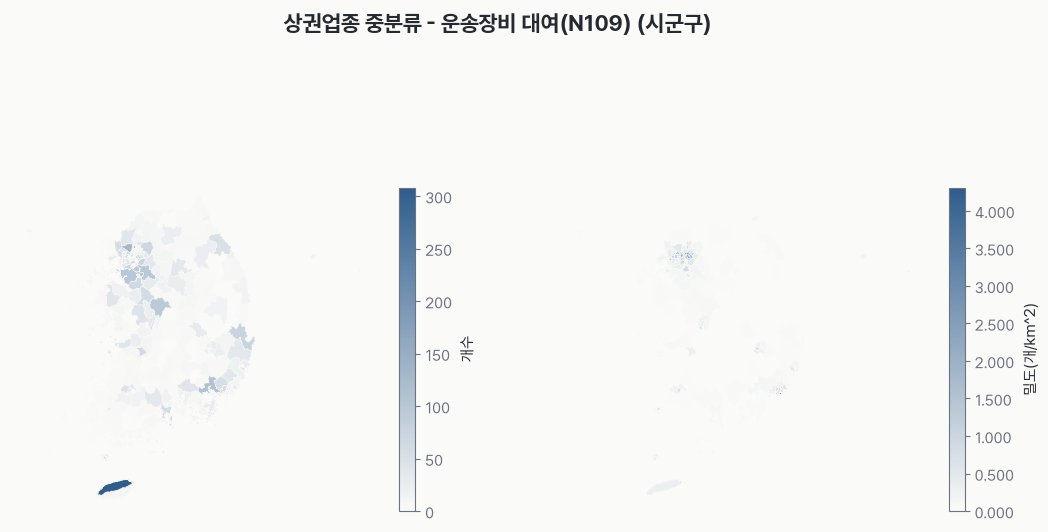

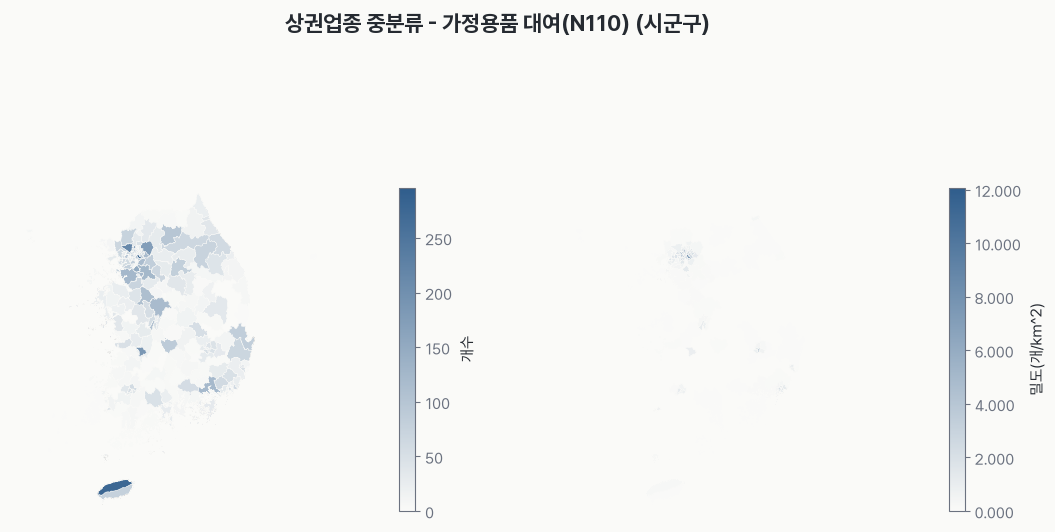

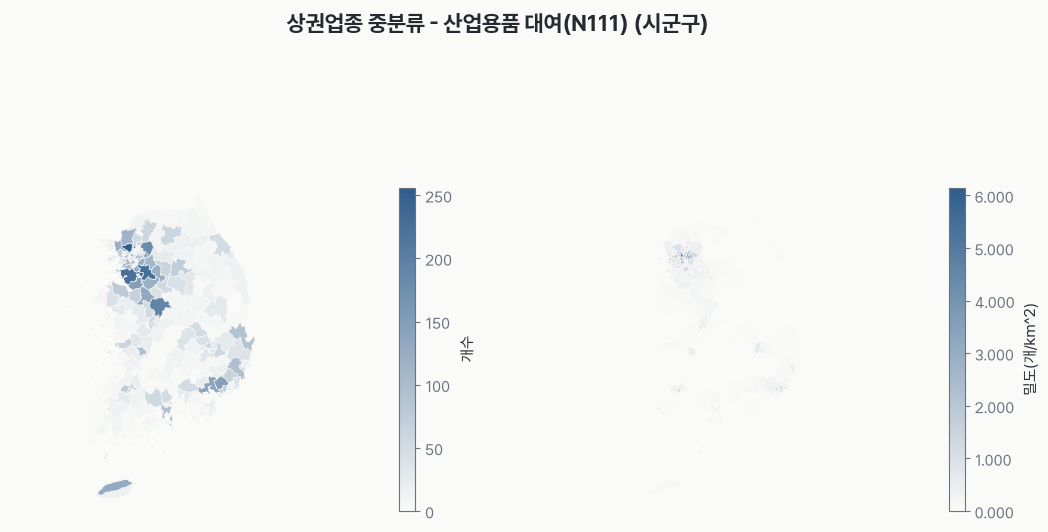

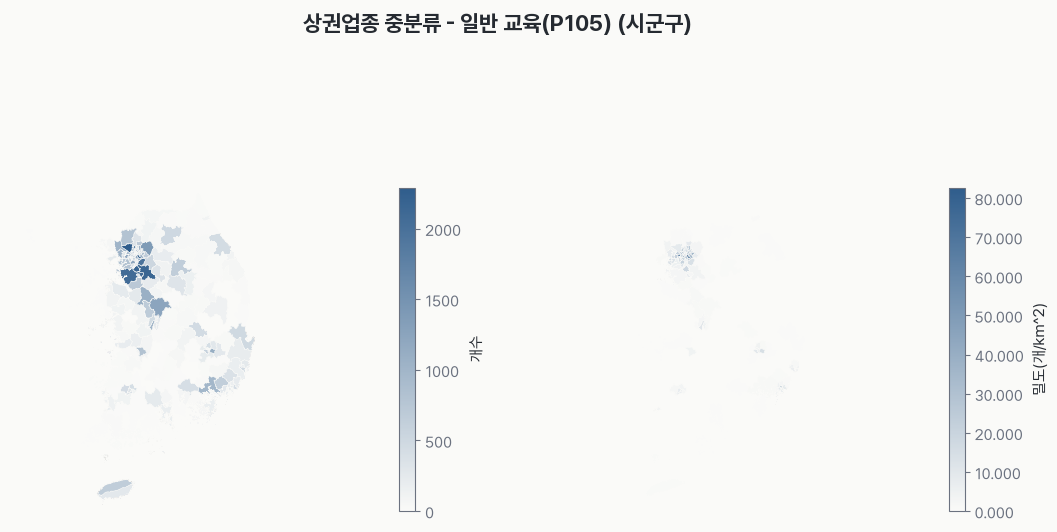

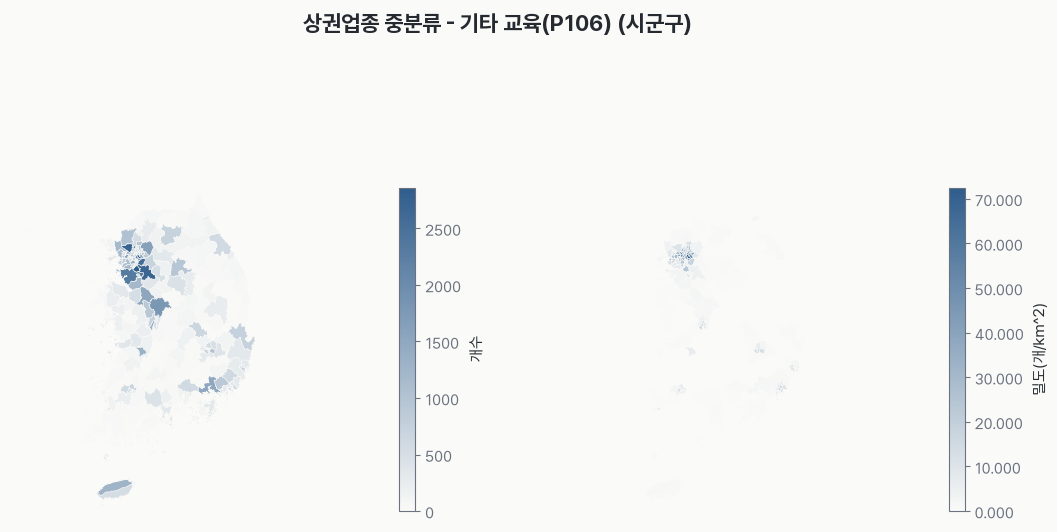

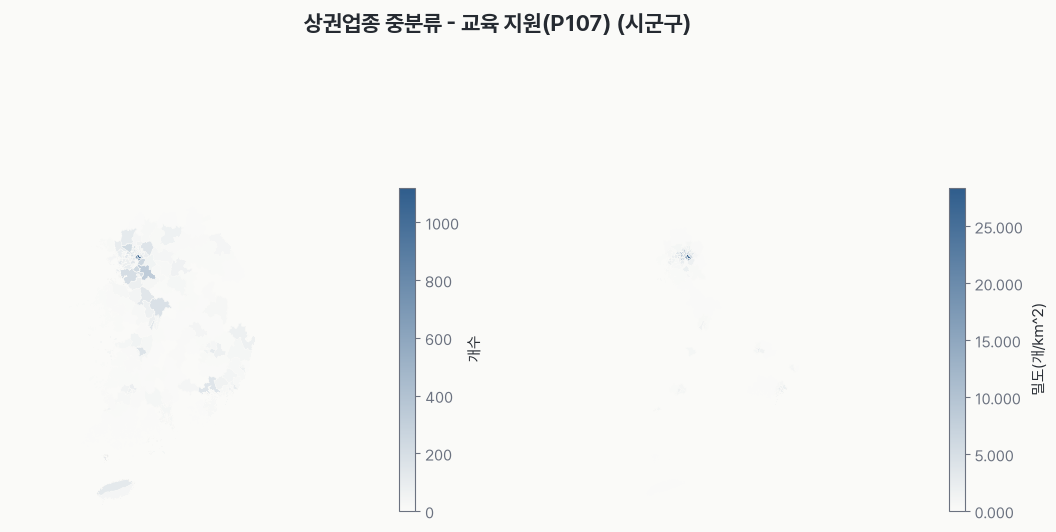

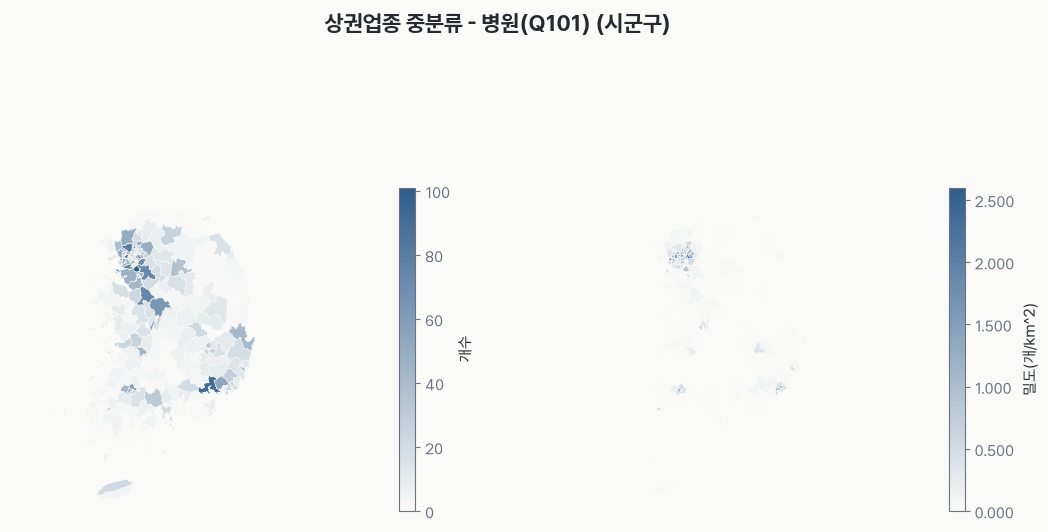

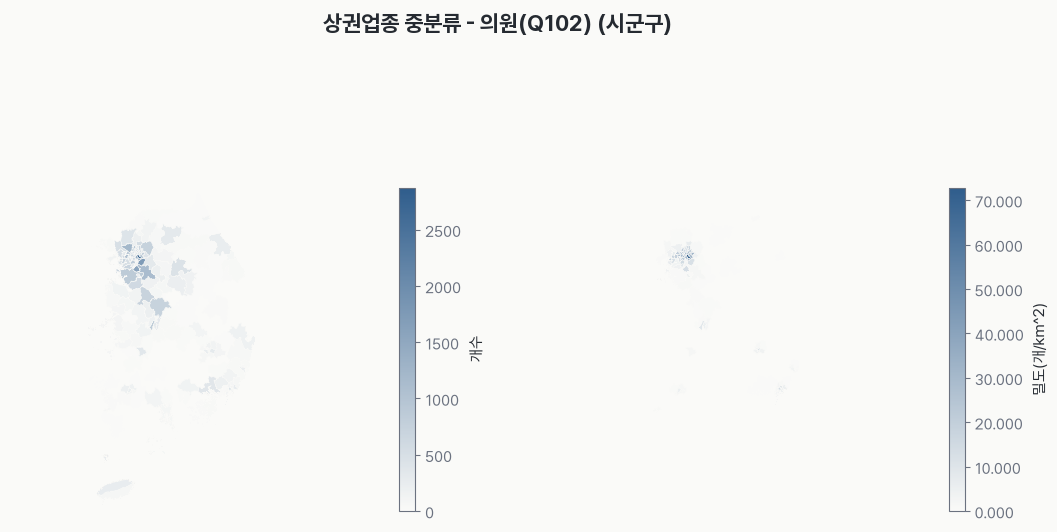

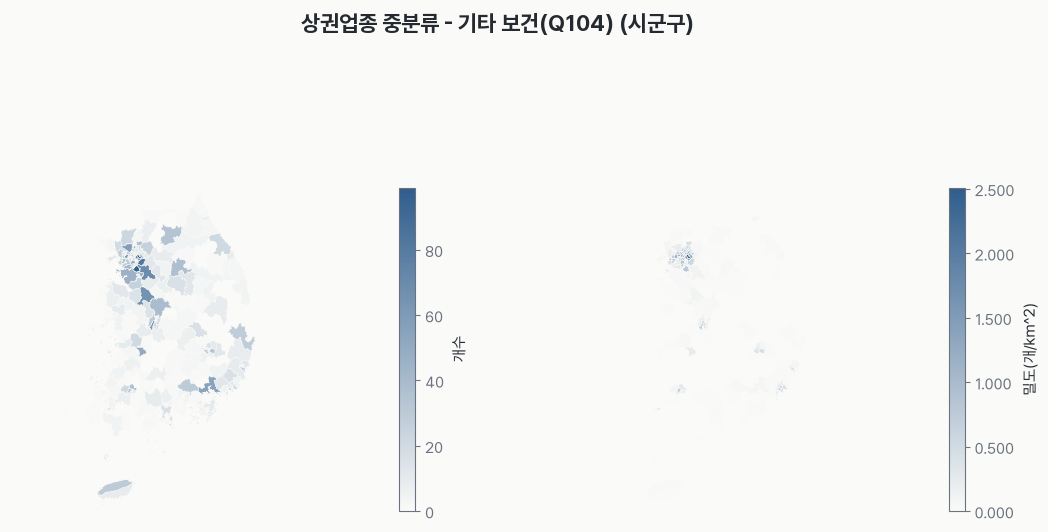

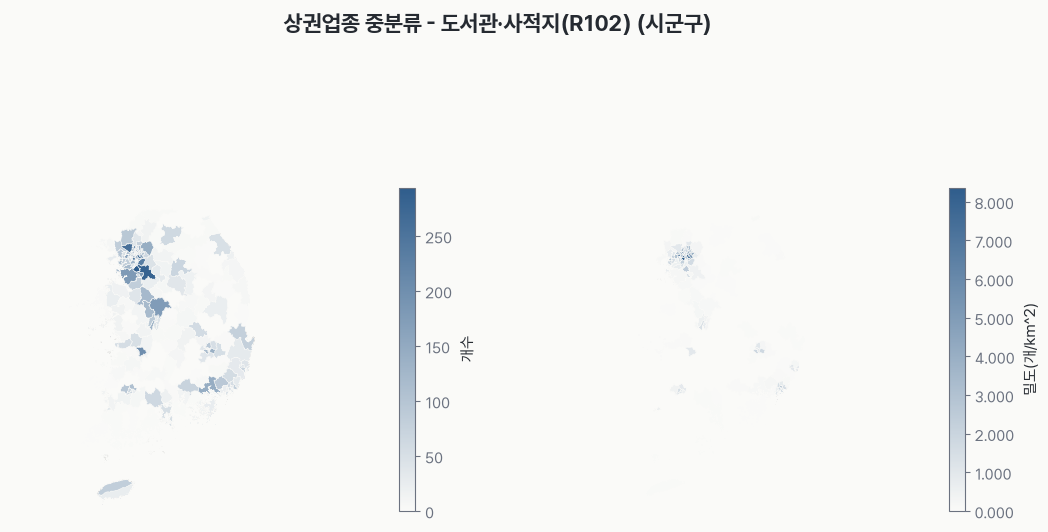

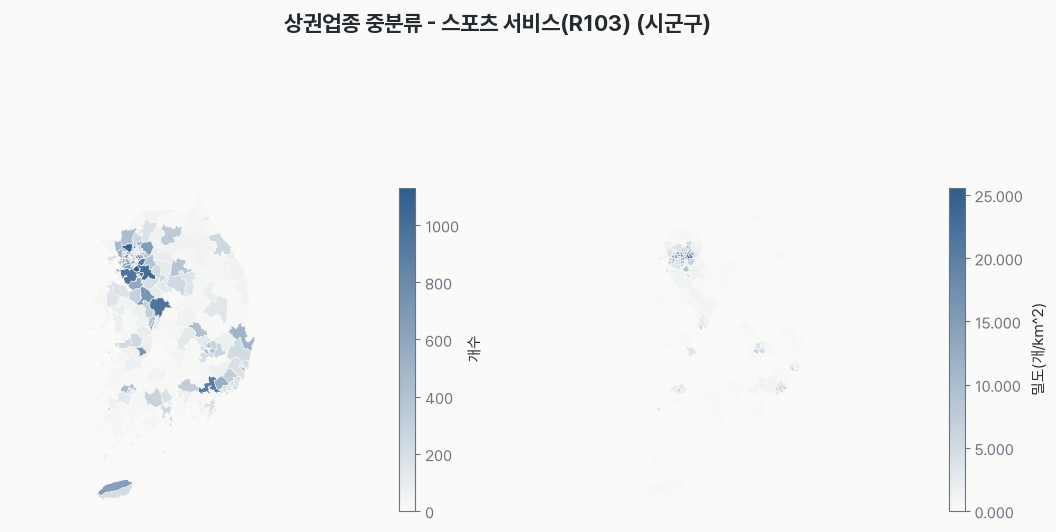

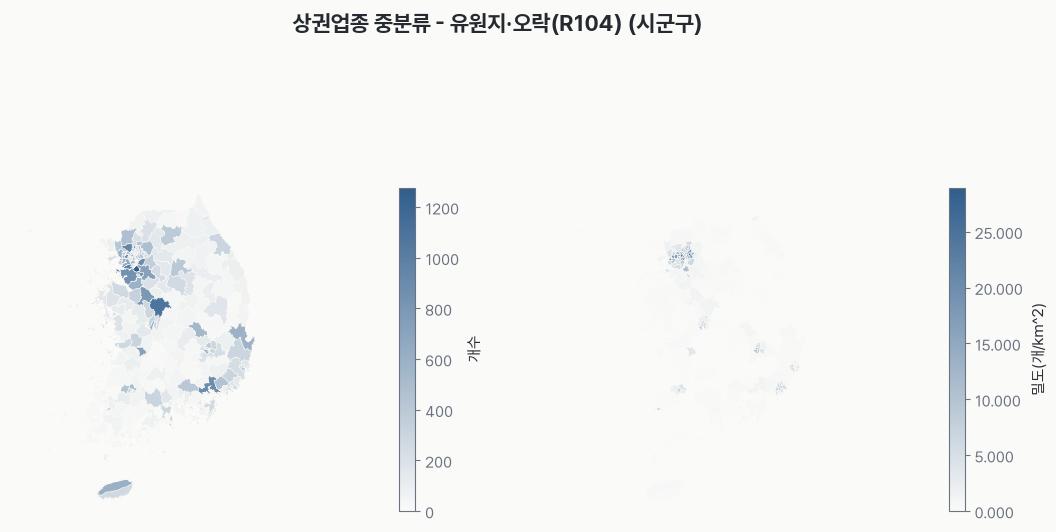

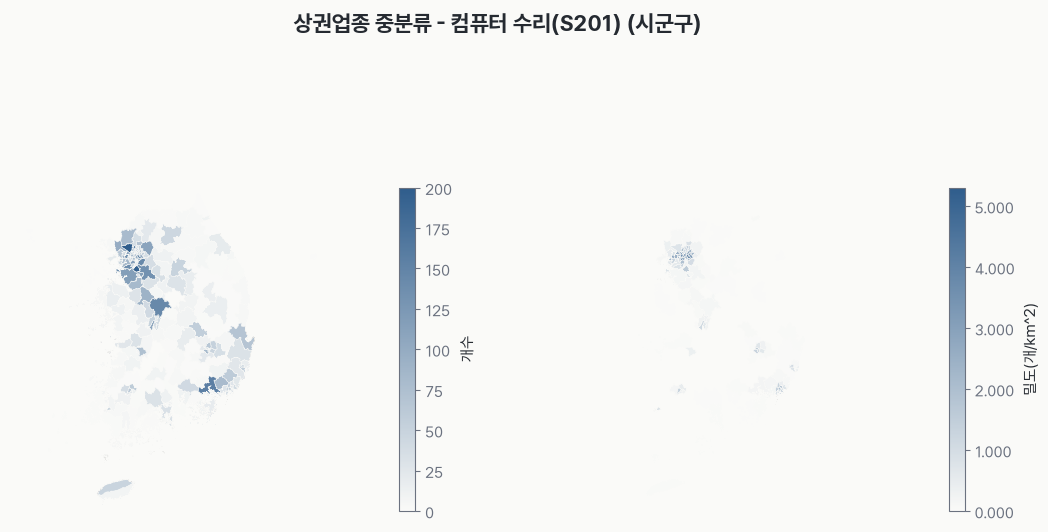

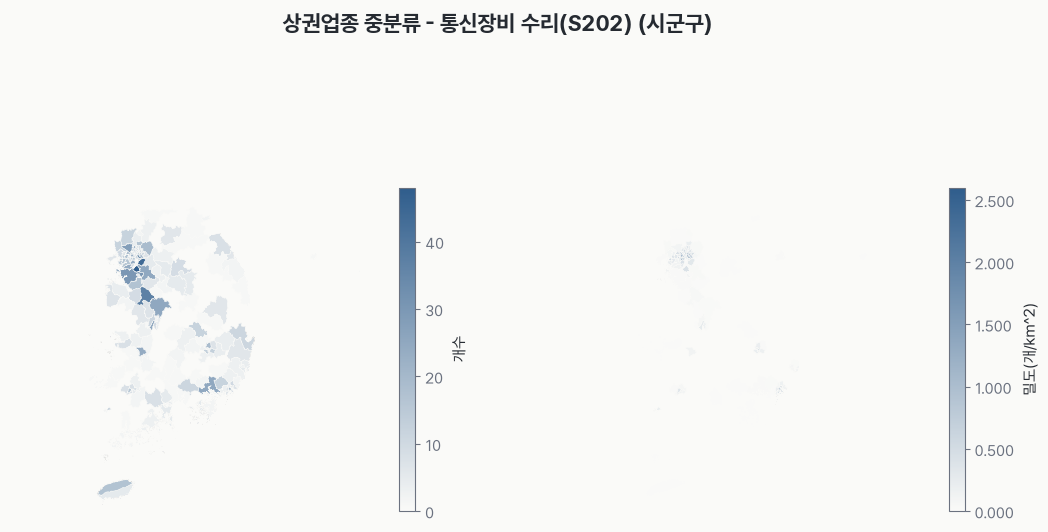

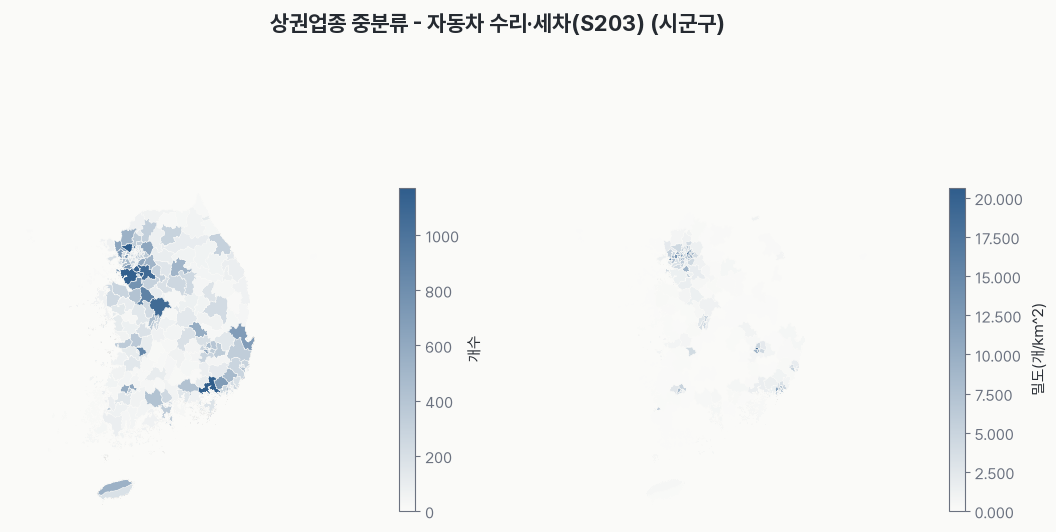

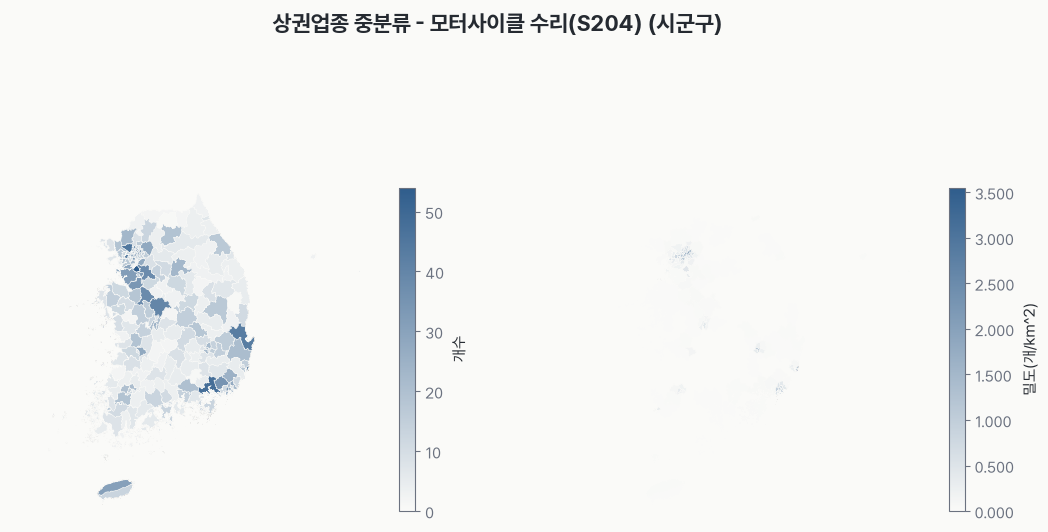

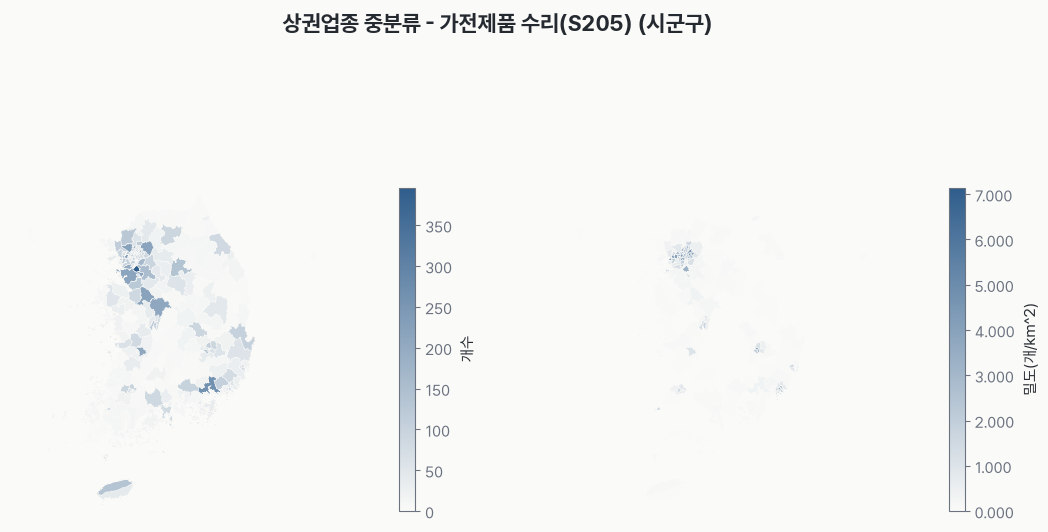

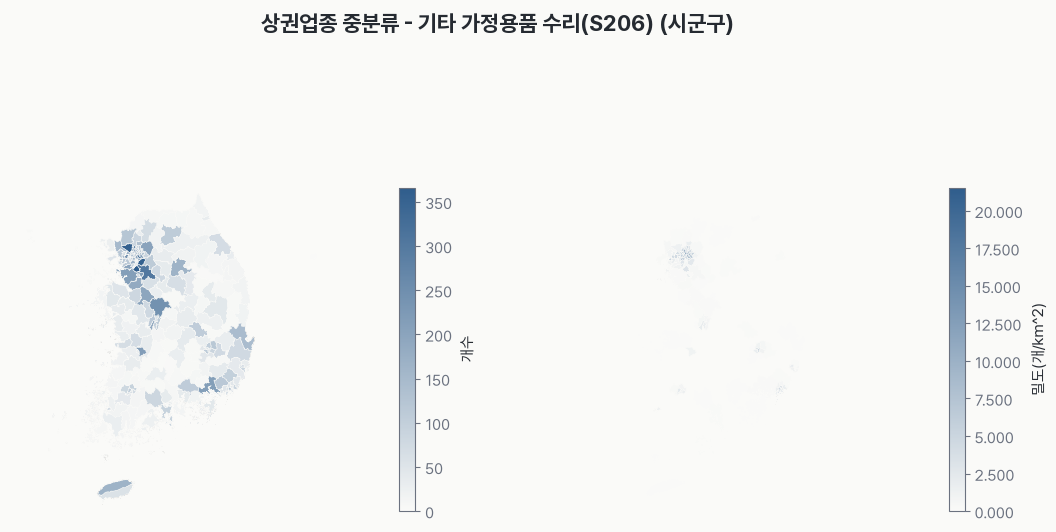

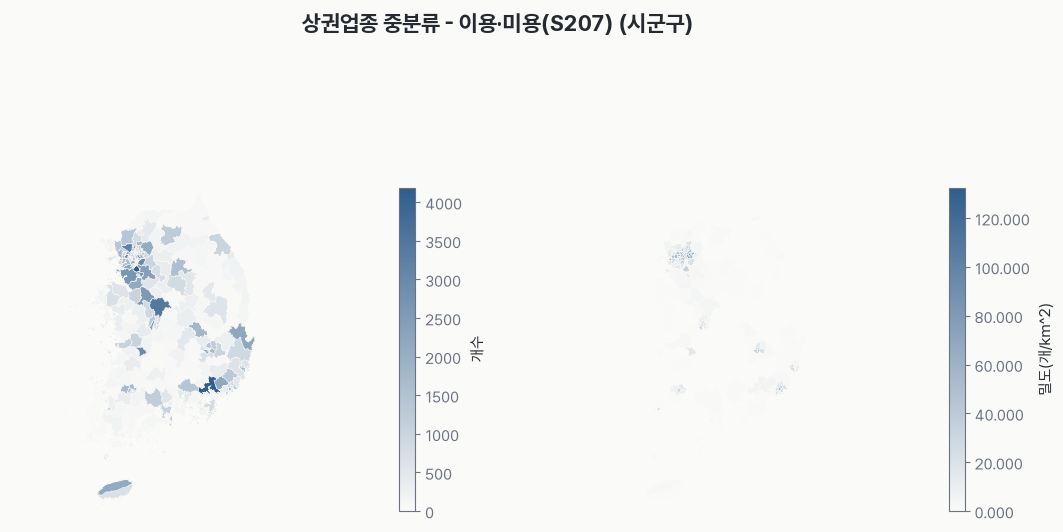

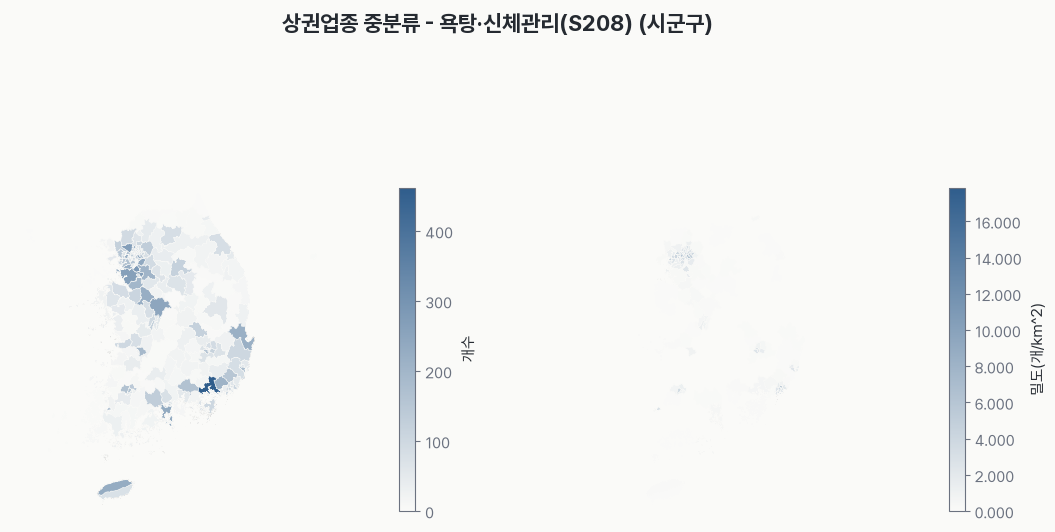

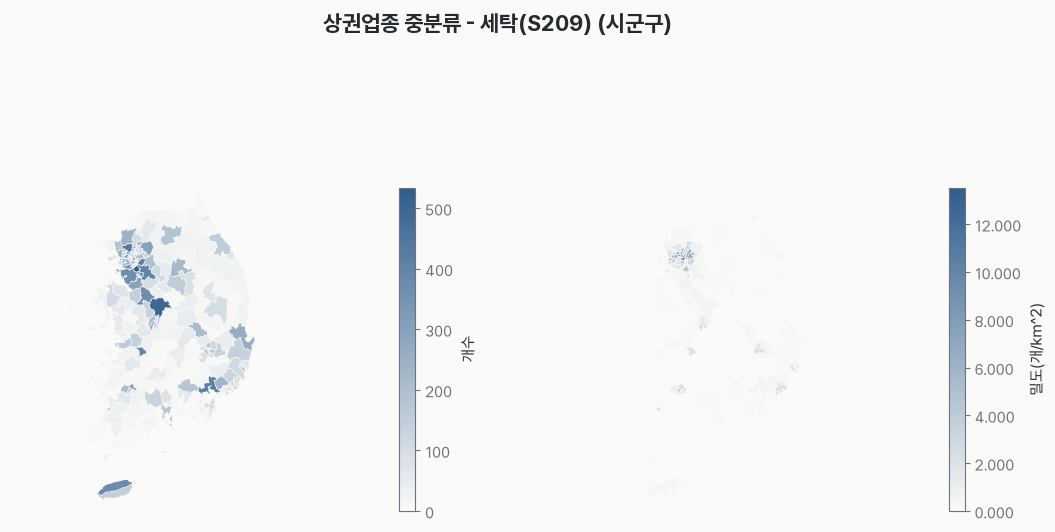

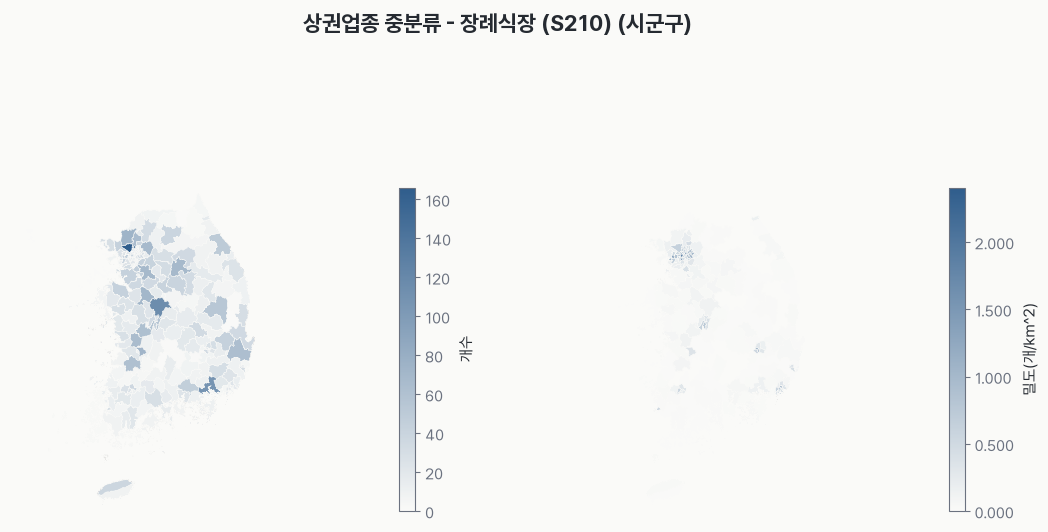

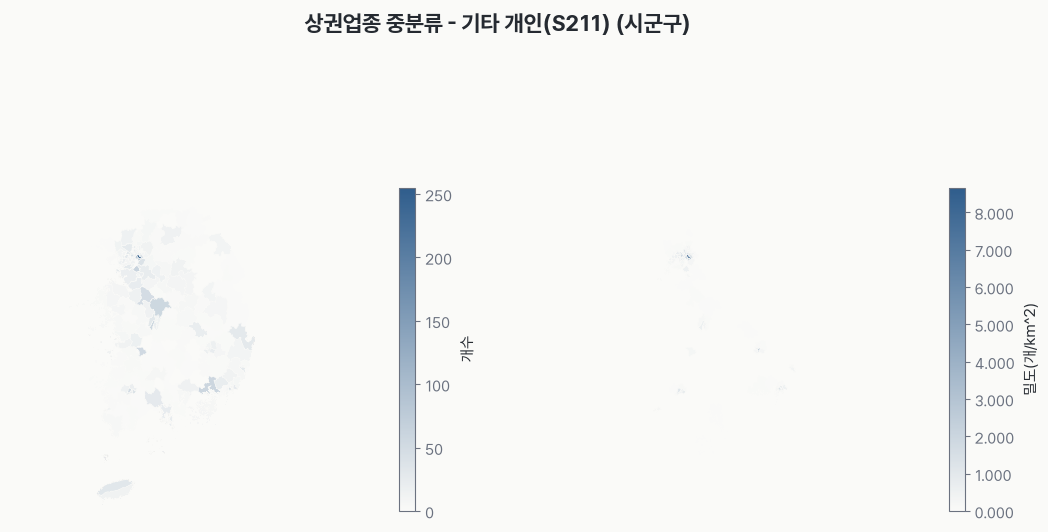

In [17]:
for count_col, density_col in zip(mid_count_columns, mid_density_columns):
    label = count_col.replace("상권중분류수_", "")
    plot_count_density_pair(count_col, density_col, f"상권업종 중분류 - {label}")

### 13-4. 관광연관 대분류 3종 개수·밀도

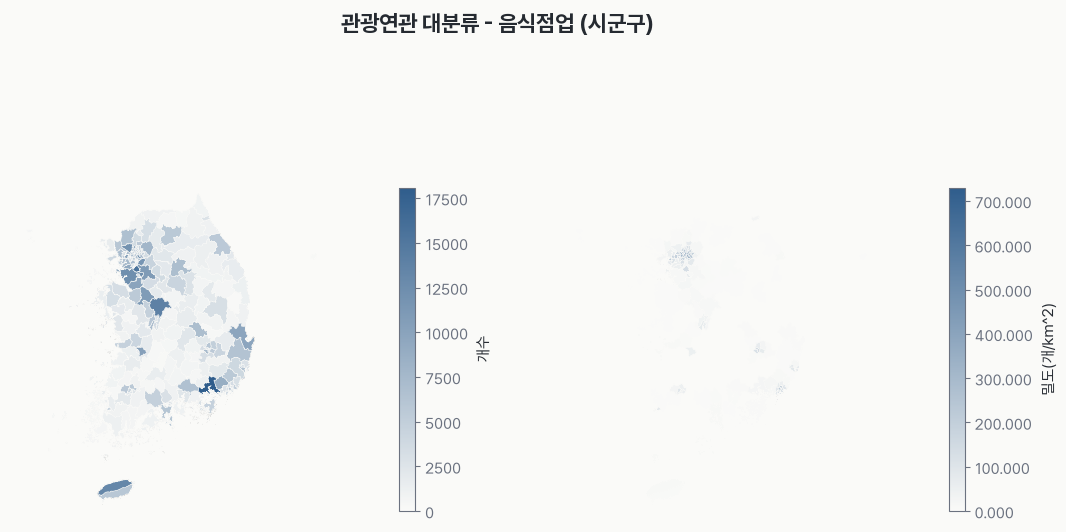

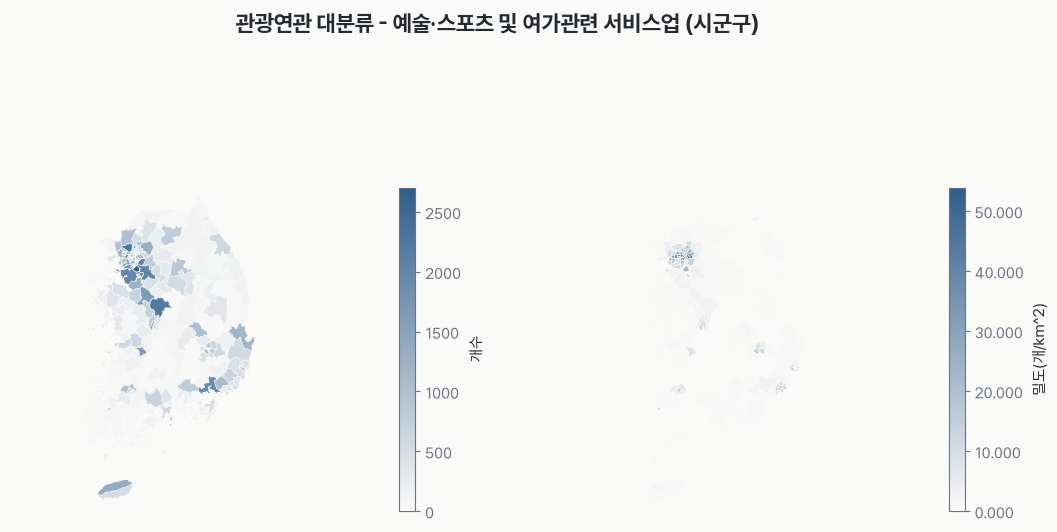

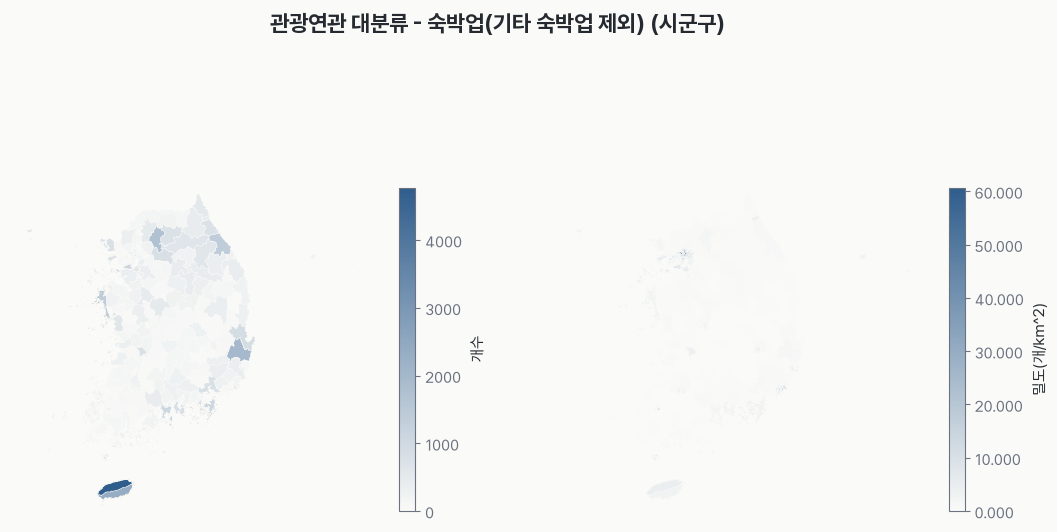

In [18]:
MAJOR_GROUP_LABELS = {
    "관광대분류수_음식점업": "음식점업",
    "관광대분류수_예술스포츠여가": "예술·스포츠 및 여가관련 서비스업",
    "관광대분류수_숙박업_기타제외": "숙박업(기타 숙박업 제외)",
}
for count_col, label in MAJOR_GROUP_LABELS.items():
    density_col = count_col.replace("관광대분류수_", "관광대분류밀도_")
    plot_count_density_pair(count_col, density_col, f"관광연관 대분류 - {label}")

### 13-5. 그 외 관광연관업종 3종 개수·밀도

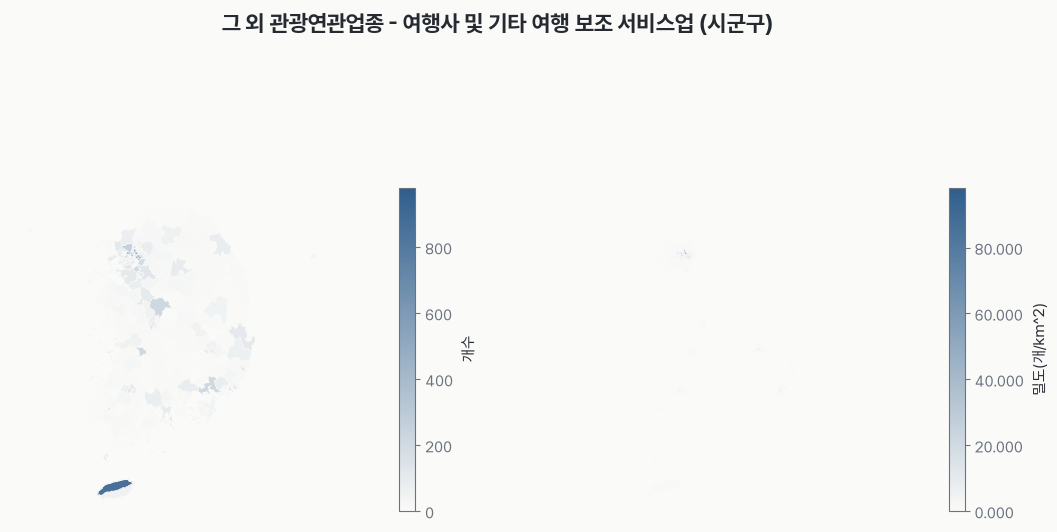

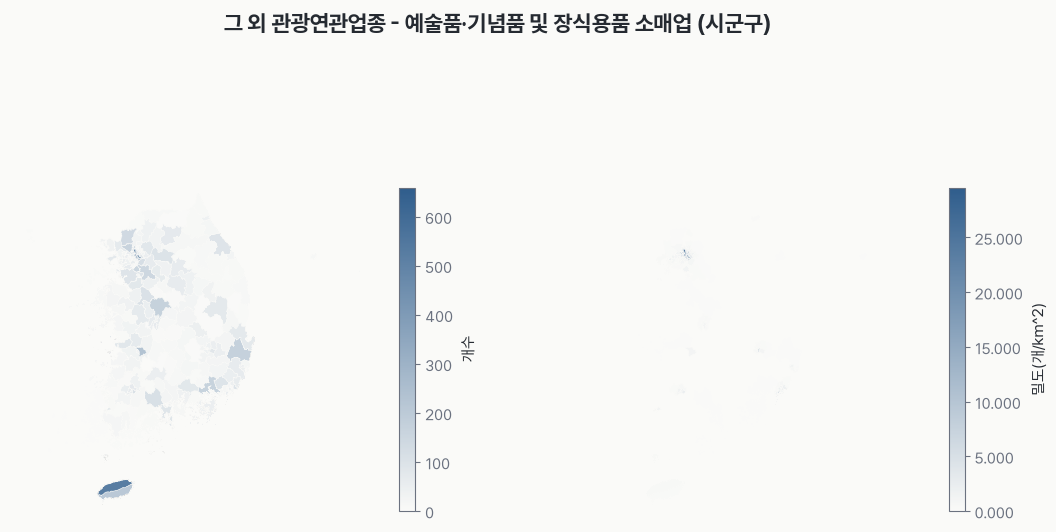

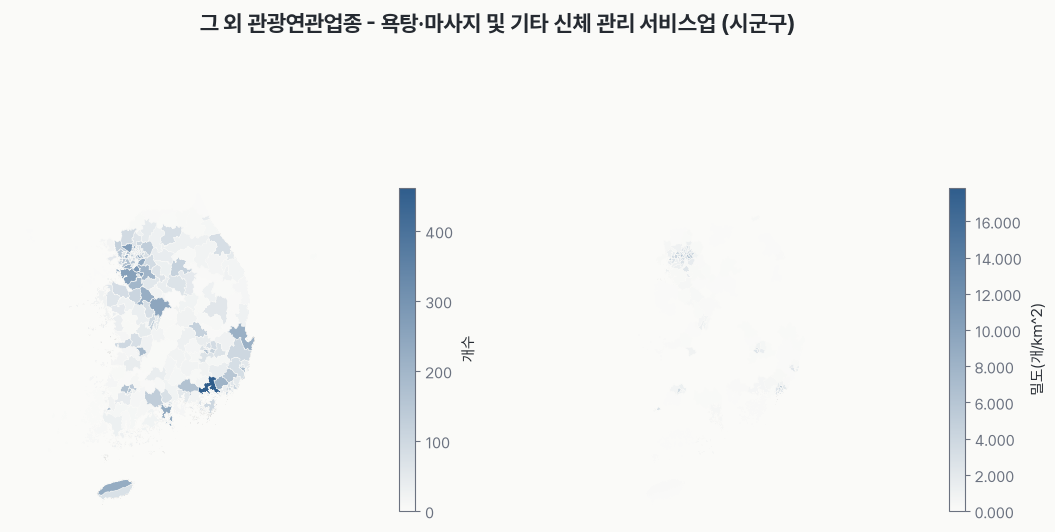

In [19]:
OTHER_GROUP_LABELS = {
    "관광기타업종수_여행사": "여행사 및 기타 여행 보조 서비스업",
    "관광기타업종수_기념품장식품소매": "예술품·기념품 및 장식용품 소매업",
    "관광기타업종수_욕탕신체관리": "욕탕·마사지 및 기타 신체 관리 서비스업",
}
for count_col, label in OTHER_GROUP_LABELS.items():
    density_col = count_col.replace("관광기타업종수_", "관광기타업종밀도_")
    plot_count_density_pair(count_col, density_col, f"그 외 관광연관업종 - {label}")

### 13-6. 관광연관업종 개수 총합

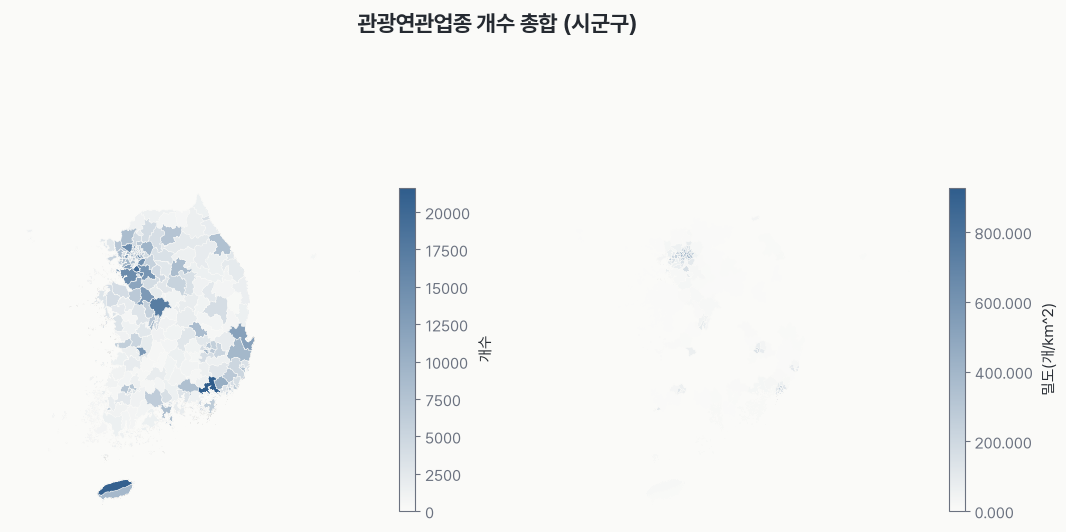

In [20]:
plot_count_density_pair("관광연관업종수_총합", "관광연관업종밀도_총합", "관광연관업종 개수 총합")

## 14. 핵심 결과와 한계

- 국민여행조사 전용 지역코드 229개 시군구를 key로, 면적·관광지유형별
  개수와 밀도·상권업종 중분류(75종) 개수와 밀도·관광연관 대분류
  3종과 그 외 관광연관업종 3종의 개수와 밀도·관광연관업종 총합을
  결합해 `outputs/260722_시군구_관광연관지표_와이드테이블/tables/`에
  저장했다.
- 군위군은 이 노트북의 key 테이블에서만 대구광역시로 고쳤고 원본
  지역코드 CSV는 그대로 두었다. 인천 남구/미추홀구도 결합 시점에만
  지역코드가 쓰는 옛 이름으로 통일했다.
- 관광지·상권업종 데이터는 모두 key 테이블과 outer merge 후 미매칭이
  없음을 확인했다(주소 문자열 파싱 결과 854건 전량, 상가정보
  약 269만 건 전량 결합됨).
- 시군구 면적은 EPSG:5179로 재투영해 계산했고, 전국 합계는 약
  100,804 km^2로 실제 국토 면적과 근접했다.
- 상권업종 중분류 카운팅은 2025년 12월 말 기준 소상공인시장진흥공단
  상가(상권)정보 스냅샷 기준이며, 개업·폐업 시점을 반영한 유효 사업체
  수는 아니다.
- "관광과 관련 있다고 판단한" 그 외 업종(여행사, 기념품·장식품
  소매업, 욕탕·신체관리서비스업)은 분석자의 판단에 따른 선정이며,
  다른 관광연관 후보 업종을 추가로 검토할 수 있다.